# Lending Club Loan Approval System

## Business Background

Lending Club is a peer-to-peer lending company where individuals can borrow loans, and investors can fund those loans. Lending Club was founded in 2006 by Renaud Laplanche as a peer-to-peer (P2P) lending platform in San Francisco. It was one of the pioneers in the online lending space, where individual borrowers could obtain loans, and individual or institutional investors could invest in these loans to earn interest. The platform allowed for a more direct connection between lenders and borrowers, bypassing traditional banking intermediaries.

Read more here https://en.wikipedia.org/wiki/LendingClub

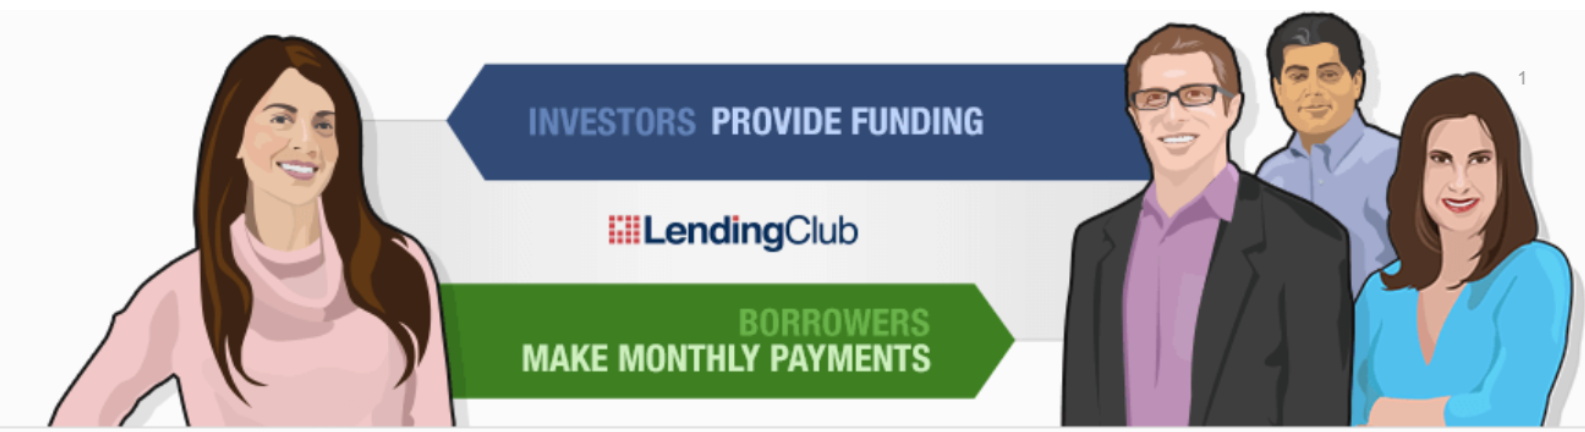

## Problem Statement

Now, whenever *Lending Club* approves a loan, there are two ways in which it is at risk:
- If LC approves a loan and the borrower fails to repay it on time
- If LC rejects a loan despite the borrower being capable of repaying the loan

Defaulting on loans can lead to significant financial losses for both the platform and investors. Similarly, not providing loans to credit-worthy customers can lead to missing out on potential revenue and profits. Therefore, a robust loan approval system is the need of the hour.

In the current loan approval process, underwriters evaluate loan applications by manually reviewing credit scores, income, debt, etc. and then, based on several parameters, either approve or reject a loan. This process is time-consuming and prone to errors.

Hence, Lending Club wants to build a loan approval system using Machine Learning models to automatically assess whether a given loan is likely to be repaid or whether the borrower is likely to default.

This is where you come in! As a budding data scientist, your goal is to help out Lending Club in creating this ML model that helps them predict whether a loan is likely to default or not.

## Data Understanding

You have been provided with around 38k loan application data from the Lending Club's website. The different columns and their description are mentioned below:

| Column Name         | Description                                                                                                                                                    |
|---------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| id                  | A unique LC assigned ID for the loan listing. *(Integer)*                                                                                                       |
| member_id           | A unique LC assigned ID for the borrower member. *(Integer)*                                                                                                    |
| loan_amnt           | The listed amount of the loan applied for by the borrower. If at some point the credit department reduces the loan amount, it will be reflected in this value. *(Float)* |
| term                | The number of payments on the loan. Values are in months and can be either 36 or 60. *(Integer)*                                                                 |
| int_rate            | Interest rate on the loan. *(Float)*                                                                                                                            |
| installment         | The monthly payment owed by the borrower if the loan originates. *(Float)*                                                                                       |
| grade               | LC assigned loan grade. *(Categorical/String)*                                                                                                                  |
| sub_grade           | LC assigned loan subgrade. *(Categorical/String)*                                                                                                               |
| emp_length          | Employment length in years. Possible values are between 0 and 10, where 0 means less than one year and 10 means ten or more years. *(Integer)*                   |
| home_ownership      | The home ownership status provided by the borrower during registration. Values are: RENT, OWN, MORTGAGE, OTHER. *(Categorical/String)*                           |
| annual_inc          | The self-reported annual income provided by the borrower during registration. *(Float)*                                                                         |
| verification_status | Indicates if income was verified by LC, not verified, or if the income source was verified. *(Categorical/String)*                                               |
| purpose             | A category provided by the borrower for the loan request. *(Categorical/String)*                                                                                |
| dti                 | A ratio calculated using the borrower’s total monthly debt payments (excluding mortgage and the requested LC loan), divided by the borrower’s self-reported income. *(Float)* |
| delinq_2yrs         | The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years. *(Integer)*                                         |
| inq_last_6mths      | The number of inquiries in the past 6 months (excluding auto and mortgage inquiries). *(Integer)*                                                                |
| open_acc            | The number of open credit lines in the borrower's credit file. *(Integer)*                                                                                       |
| pub_rec             | Number of derogatory public records. *(Integer)*                                                                                                                |
| revol_bal           | Total credit revolving balance. *(Float)*                                                                                                                       |
| revol_util          | Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. *(Float)*                             |
| total_acc           | The total number of credit lines currently in the borrower's credit file. *(Integer)*                                                                            |
| last_pymnt_amnt     | Last total payment amount received. *(Float)*                                                                                                                   |
| loan_status         | Current status of the loan. *(Categorical/String)*                                                                 
                  |

...

## Starter Code

#### Challenges:
1. **Data Imbalance:**

   This imbalance makes it difficult to rely on traditional metrics like accuracy, as a model predicting “fully paid” for everyone might seem accurate but would miss identifying at-risk customers.

2. **Feature Selection:**

   Improves model performance by focusing on relevant features, reduces overfitting, enhances interpretability, and makes models faster to train and easier to understand.


3. **Choosing the Right Metrics:**

  Accuracy is misleading for loan approval prediction. So, focus has to be on both Recall (correctly identifying defaulters) and Precision (not mislabeling potential customers) and F1 Score,to ensure that the company doesn't waste resources on false positives or miss out on potential customers.

4. **Overfitting vs. Underfitting:**

  Balancing model complexity is crucial. Simple models (underfitting) fail to capture important patterns, while complex models (overfitting) may perform well on training data but poorly on new customers.

### Necessary Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
pd.set_option('display.max_columns', None)
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')

### Data Loading

In [6]:
## Load the dataset from CSV
lending_club_ds = pd.read_csv("loans.csv")

In [7]:
# Looking at head
lending_club_ds.head().T

,0,1,2,3,4
id,1077501,1077430,1077175,1076863,1075269
member_id,1296599.0,1314167.0,1313524.0,1277178.0,1311441.0
loan_amnt,5000.0,2500.0,2400.0,10000.0,5000.0
term,36 months,60 months,36 months,36 months,36 months
int_rate,10.65%,15.27%,15.96%,13.49%,7.90%
installment,162.87,59.83,84.33,339.31,156.46
grade,B,C,C,C,A
sub_grade,B2,C4,C5,C1,A4
emp_length,10+ years,< 1 year,10+ years,10+ years,3 years
home_ownership,RENT,RENT,RENT,RENT,RENT


In [8]:
#Looking at Tail
lending_club_ds.tail().T

,38765,38766,38767,38768,38769
id,92187,90665,90395,90376,87023
member_id,92174.0,90607.0,90390.0,89243.0,86999.0
loan_amnt,2500.0,8500.0,5000.0,5000.0,7500.0
term,36 months,36 months,36 months,36 months,36 months
int_rate,8.07%,10.28%,8.07%,7.43%,13.75%
installment,78.42,275.38,156.84,155.38,255.43
grade,A,C,A,A,E
sub_grade,A4,C1,A4,A2,E2
emp_length,4 years,3 years,< 1 year,< 1 year,< 1 year
home_ownership,MORTGAGE,RENT,MORTGAGE,MORTGAGE,OWN


In [9]:
#Visualize missing values
#import missingno as msno
#msno.bar(lending_club_ds)

### Observations
Initial data auditing - displaying the first few records with 'head' and last few rows with 'tail'

1.Feature Types:
* Numerical: loan_amnt, installment, annual_inc, dti, etc.
* Categorical: term, grade, home_ownership, purpose, etc.

2.Some data needs cleanup.those needs cleanup noticed now are -
* term (months stored as string)
* int_rate (percentage stored as a string)
* emp_length (string format with years)
* revol_util (percentage stored as a string)

3.id,memberid may not be needed,for now this appears to be identification numbers.


In [9]:
## Check the dataframe structure - datatypes and number of non-null rows
lending_club_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   38770 non-null  int64  
 1   member_id            38770 non-null  float64
 2   loan_amnt            38770 non-null  float64
 3   term                 38770 non-null  object 
 4   int_rate             38770 non-null  object 
 5   installment          38770 non-null  float64
 6   grade                38770 non-null  object 
 7   sub_grade            38770 non-null  object 
 8   emp_length           37734 non-null  object 
 9   home_ownership       38770 non-null  object 
 10  annual_inc           38770 non-null  float64
 11  verification_status  38770 non-null  object 
 12  purpose              38770 non-null  object 
 13  dti                  38770 non-null  float64
 14  delinq_2yrs          38770 non-null  float64
 15  inq_last_6mths       38770 non-null 

Dataset Overview:
* Total Rows: 38,770
* Total Columns: 23
* Dataset contains datatypes: float64(12),objects(10),int64(1)
* Feature Types:
    * Numerical: id, member_id,loan_amnt, installment, annual_inc, dti, delinq_2yr,inq_last_6mths,open_acc,pub_rec,revol_bal,total_acc,total_acc,last_pymnt_amnt
    * Categorical: term, grade,sub_grade,emp_length, home_ownership, verification_status,purpose, revol_util,loan_status
* loan_status appers to be target variable
* emp_length has less rows -only 37,734 rows. This means emp_length has some null values.

In [10]:
## Check the shape
lending_club_ds.shape
print(f"Total number of rows { lending_club_ds.shape[0]} and Total number of columns {lending_club_ds.shape[1]}")

Total number of rows 38770 and Total number of columns 23


**Total number of rows are 38770 and Total number of columns are 23**

In [12]:
#View the columns of the dataset
lending_club_ds.columns

Index(['id', 'member_id', 'loan_amnt', 'term', 'int_rate', 'installment',
       'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'last_pymnt_amnt', 'loan_status'],
      dtype='object')

* id and member_id appears to be unique identification number. This won't give meaningful patterns for prediction.
* grade and sub_grade: looking at definition of both of these appears to be have similar information,need to see the influence/correlation in generalizing the data. otherwise one of them can be dropped.
* Loan_status:  might give info on loan can be approved or person can be defaulter or whether the payment is rolling with the memeber. So this shall be Target variable.
* loan_amt along with annual_inc might play good role with loan_status, can influence member can be risk or not.

In [11]:
## Check the missing values across the columns
missing_data = pd.concat([lending_club_ds.isnull().sum(),lending_club_ds.isnull().mean(), lending_club_ds.isnull().mean() * 100],axis=1)
missing_data.columns=['count','mean','%']
missing_data.sort_values(by= 'count', ascending=False)

,count,mean,%
emp_length,1036,0.026722,2.672169
revol_util,50,0.001290,0.128966
id,0,0.000000,0.000000
term,0,0.000000,0.000000
int_rate,0,0.000000,0.000000
member_id,0,0.000000,0.000000
loan_amnt,0,0.000000,0.000000
grade,0,0.000000,0.000000
installment,0,0.000000,0.000000
home_ownership,0,0.000000,0.000000


#### Observations
* emp_length has 1036 nulls
* revol_util has 50 nulls
* otherwise rest of the features have non-null values

* emp_length has 2.7% and revol_util has .13% missing values respectively.The feature revol_until has very negligible amount of missingvalues.
* The feature 'last_pymnt_amnt', may not be needed, as this information is not available at time of loan approval.

In [13]:
# Separate categorical and numerical features
categorical_features = lending_club_ds.select_dtypes(include=['object']).columns
numerical_features = lending_club_ds.select_dtypes(include=['number']).columns

In [14]:
lending_club_ds[categorical_features].describe()

,term,int_rate,grade,sub_grade,emp_length,home_ownership,verification_status,purpose,revol_util,loan_status
count,38770,38770,38770,38770,37734,38770,38770,38770,38720,38770
unique,2,371,7,35,11,5,3,14,1088,2
top,36 months,10.99%,B,A4,10+ years,RENT,Not Verified,debt_consolidation,0%,Fully Paid
freq,29096,928,11726,2874,8547,18550,16732,18145,960,33136


#### Interpretation of Frequency Distribution for Categorical Features.
##### Term
- **Definition**:The number of payments on the loan. Values are in months and can be either 36 or 60. *(Integer)
- **Count**: 38,770 non-null payments of loan.No missing values.
- **Unique**: two types of payment of loan.
- **Most Frequent**: Most often is 36 months of loan payment, and has 29,096 member took this type of loan payment.
##### int_rate
- **Definition**:Interest rate on the loan. *(Float)
- **Count**: 38,770 non-null interest rate records.No missing values.
- **Most Frequent**: 928 members have taken 10.99% interest rates, and this is appears to be more polular interest rate.
##### grade
- **Definition**:The company "Lending Club" assigned loan grade. *(Categorical/String)
- **Count**: 38,770 non-null grade records.No missing values.
- **Unique**: 7 different types of grade are allocated to memebers.
- **Most Frequent**: 11726 members are given with 'B' Grade.
##### sub_grade
- **Definition**:The company "Lending Club" assigned loan subgrade. *(Categorical/String)
- **Count**: 38,770 non-null subgrade records.No missing values.
- **Unique**: 35 different types of subgrade are given to memebers.
- **Most Frequent**: 2,874 members are given with 'A4' Grade.Interesting to note, 'B' grades more as per  stats from 'grade'. Need to check how these two influencing in generalizing the model, Otherwise one of them can be dropped.
##### emp_length
- **Definition**:Employment length in years. Possible values are between 0 and 10, where 0 means less than one year and 10 means ten or more years. *(Integer)
- **Count**: 37,734 non-null emp_length records. 1,036 are missed the values.
- **Unique**: 11 different types of emp_length.
- **Most Frequent**: 8,547 members are with 10+ years of employment.
##### home_ownership
- **Definition**:The home ownership status provided by the borrower during registration. Values are: RENT, OWN, MORTGAGE, OTHER. *(Categorical/String)
- **Count**: 38,770 non-null home_ownership records. No missed the values.
- **Unique**: 5 different types of home_ownership.
- **Most Frequent**: 'RENT' type home owner are the highest with 18,550 members.
##### verification_status
- **Definition**:Indicates if income was verified by Lending Club, not verified, or if the income source was verified. *(Categorical/String)
- **Count**: 38,770 non-null values records. No missed the values.
- **Unique**: 3 types.
- **Most Frequent**: 16,732 members are with 'not verified' status and being highest.
##### purpose
- **Definition**:A category provided by the borrower for the loan request. *(Categorical/String)
- **Count**: 38,770 non-null values records. No missed the values.
- **Unique**: 14 types.
- **Most Frequent**: 'debt_consolidation' status being highest with	 members 18,145.
##### revol_util
- **Definition**:Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. *(Float)
- **Count**: 38,770 non-null values records. No missed the values.
- **Most Frequent**: 960 members are with '0%' revolving line utilization rate
##### loan_status
- **Definition**:Current status of the loan. *(Categorical/String)*
- **Count**: 38,770 non-null values records. No missed the values.
- **Unique**: 2 types
- **Most Frequent**: 33,136members are with 'Fully Paid' status. This shall be the target  variable
  

In [16]:
lending_club_ds[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
id,38770.0,676995.973072,209022.602925,54734.00,512703.2500,657993.50,828720.25,1077501.00
member_id,38770.0,843089.188367,264134.540029,70699.00,661910.0000,841092.00,1037009.50,1314167.00
loan_amnt,38770.0,11069.122388,7362.292600,500.00,5325.0000,9737.50,15000.00,35000.00
installment,38770.0,322.629489,208.592815,15.69,165.7400,278.15,426.10,1305.19
annual_inc,38770.0,68800.252230,64161.315787,4000.00,40000.0000,58923.50,82000.00,6000000.00
dti,38770.0,13.276704,6.676355,0.00,8.1300,13.37,18.56,29.99
delinq_2yrs,38770.0,0.146660,0.492197,0.00,0.0000,0.00,0.00,11.00
inq_last_6mths,38770.0,0.871473,1.071444,0.00,0.0000,1.00,1.00,8.00
open_acc,38770.0,9.278850,4.401871,2.00,6.0000,9.00,12.00,44.00
pub_rec,38770.0,0.055404,0.237727,0.00,0.0000,0.00,0.00,4.00


* No negative values, so appears to be meaningful values, however there are outliers.
* id and memeber_id appears to be unique identification numbers, these two can be dropped, as does not help in giving patterns where model can learn.
* outliers can be seen with revol_bal,annul_inc, last_pymnt_amt. Need to explore further whether these can be dropped or allow model to learn.

### Interpretation of Descriptive Statistics for Numerical Features
#### loan_amnt
- **Definition**:The listed amount of the loan applied for by the borrower. If at some point the credit department reduces the loan amount, it will be reflected in this value. *(Float)*
- **Count**:38,770 no missing values
- **Mean**: 11069.12 indicating majority of the people took loan amount 11,000
- **Standard Deviation**: 7362.29 , shows majority memebers took maximum of loan amount is around 18,000
- **Min and Max**:  min is 500 and max is 35,00
- **IQR (Interquartile Range - 25% to 75%)**: 5,325 to 15,000. IQR = Q3 - Q1 = 5325 - 15000
-Most loans are between 5,325 and 15,000, but the max is 35,000, indicating some higher-value loans.Since Q1 (5,325) < Median (9,737.50) < Q3 (15,000), the data appears to be right-skewed (positively skewed).
This means that a larger number of values are on the lower end, while some higher values (potential outliers)

#### installment
- **Definition**:The monthly payment owed by the borrower if the loan originates. *(Float)
- **Count**:38,770
- **Mean**:322.63 average monthly payment is around 323.
- **Standard Deviation**:208.59, very high variation,  data is highly spread out or has outliers.
- **Min and Max**: max is 1305 and min 15.69, looking at these values, there could be outliers, need to explore further.
- **Distribution**: looking at percentiles, distribution is normal but there could be outliers.
- **Percentiles**:
  - 25th percentile:165.74 ,
  - Median: 278.15
  - 75th percentile:426.10, IQR = Q3 - Q1 = 426.10 - 165.74 = 260.36, A larger IQR means the middle 50% of data is widely spread out.
  Since the mean is greater than the median, this suggests a right-skewed (positively skewed) distribution.This means there are some high values (outliers) pulling the mean upwards.

#### annual_inc
- **Definition**:The self-reported annual income provided by the borrower during registration. *(Float)
- **Count**:38,770  
- **Mean**:68800.25
- **Standard Deviation**:64161.31, very high variation.Income distribution is highly spread out.
- **Min and Max**:Min is 4,000 and  max is 6,000,000,This is an extremely wide range, indicating significant variability in the data.
- **Distribution**: majority of the member are with income from 40,000 to 82,000
- **Range**: Looking at min- max range there appears to be outliers.
- **Percentiles**:
  - 25th percentile:40000
  - Median:58923
  - 75th percentile:82000
  Since the mean > median, it suggests a right-skewed distribution. There are likely a few people with very high incomes pulling the mean upwards, which makes the distribution skewed to the right.Performing log transformations may reduce the impact of outliers and make the data more normally distributed.
#### dti
- **Definition**:A ratio calculated using the borrower’s total monthly debt payments (excluding mortgage and the requested LC loan), divided by the borrower’s self-reported income. *(Float)*
- **Count**:38770
- **Mean**:13.27
- **Standard Deviation**: 6.67
- **Min and Max**: min is 0 and max is 29.99 there don’t seem to be any extreme outliers based on this range.
- **Percentiles**:
  - 25th percentile: 8.13
  - Median: 13.37 Since mean ≈ median, we can infer that the distribution is likely symmetrical.
  - 75th percentile:18.56

#### delinq_2yrs
- **Definition**:The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years. *(Integer)
- **Count**:38770
- **Mean**:0.146660
- **Standard Deviation**:0.492197 The standard deviation is relatively low, which means the values are generally concentrated close to the mean (which is very close to 0).
- **Min and Max**:0.00 and 11.00
- **Percentiles**:
  - 25th percentile:0.00
  - Median:0.00
  - 75th percentile:0.00
Since the mean > median, it suggests that there are a few individuals who may have a significantly higher number of delinquencies (potential outliers),the data is right-skewed. Percentiles all being 0 shows that a large proportion of individuals in the dataset have zero delinquencies.

#### inq_last_6mths
- **Definition**:The number of inquiries in the past 6 months (excluding auto and mortgage inquiries). *(Integer)
- **Count**:38770
- **Mean**:0.871473 The average number of inquiries is less than 1. This means, on average, individuals have less than one inquiry in the past 6 months.
- **Standard Deviation**:1.071444
- **Min and Max**: 0.00 to 8.00
- **Percentiles**:
  - 25th percentile:1.00
  - Median:1.00
  - 75th percentile:0.00
  Since mean < median, it indicates that the data is left-skewed, meaning that the majority of the population has fewer inquiries

#### open_acc
- **Definition**:The number of open credit lines in the borrower's credit file. *(Integer)
- **Count**:38770
- **Mean**:9.278850
- **Standard Deviation**:4.401871
- **Min and Max**:2 to 44 max value of 44 indicates that there are individuals with significantly higher numbers of open accounts compared to the rest of the dataset
- **Percentiles**:
  - 25th percentile:6
  - Median:9
  - 75th percentile:12
  Since the mean ≈ median, it suggests that the distribution of this data is relatively normal or symmetric.Most individuals have between 6 and 12 open accounts,

#### pub_rec
- **Definition**:Number of derogatory public records. *(Integer)
- **Count**:38770
- **Mean**:0.055404
- **Standard Deviation**:0.237727
- **Min and Max**:0 to 4
- **Percentiles**:
  - 25th percentile:0
  - Median:0 most individuals have no occurrences of the event being measured.
  - 75th percentile:0
Since the mean > median, this suggests that the data is right-skewed, meaning there are a few individuals with higher values that are pushing the mean above the median.

#### revol_bal
- **Definition**:Total credit revolving balance. *(Float)
- **Count**:38770
- **Mean**:13297.26
- **Standard Deviation**:15861.57 Is very large, meaning that there is substantial variation in the data. Some individuals have much higher balances than others, indicating a high spread in the data.
- **Min and Max**:0 to 149588 the max value of 149,588 is quite large compared to the min value of 0, suggesting that a few individuals have much larger credit balances than the majority.
- **Percentiles**:
  - 25th percentile:3654
  - Median:8777  meaning that half of the individuals have balances less than or equal to 8,777 and the other half have balances greater than or equal to 8,777.
  - 75th percentile:16938

#### total_acc
- **Definition**:The total number of credit lines currently in the borrower's credit file. *(Integer)
- **Count**:38770
- **Mean**:22.05
- **Standard Deviation**:11.42
- **Min and Max**:2 to 90 suggesting that there are values spread across this wide range
- **Percentiles**:
  - 25th percentile:13
  - Median:20
  - 75th percentile:29
  Since the mean > median, the data is right-skewed.

#### last_pymnt_amnt
- **Definition**:Last total payment amount received. *(Float)
- **Count**:38770
- **Mean**:2735.88
- **Standard Deviation**:4486.3 indicating that the data has a high degree of variability
- **Min and Max**:0 to 36115.20 The max value is higher than the min value of 0, indicates the presence of outliers.
- **Distribution**
- **Range**:
- **Percentiles**:
  - 25th percentile:216.82
  - Median:565.40
  - 75th percentile:3425.47
  Given that the mean > median, the data appears to be right-skewed

### Data Cleaning
- Remove extra symbols, characters, etc. from appropriate columns
- Perform missing value treatment
- Check for Duplicates
- Dropping unnecessary columns
- Datatype conversions
- Outlier treatment

**Handling additional Symbols,Characters etc.,**

In [17]:
# Checking Categorocal features
lending_club_ds.select_dtypes(object)

,term,int_rate,grade,sub_grade,emp_length,home_ownership,verification_status,purpose,revol_util,loan_status
0,36 months,10.65%,B,B2,10+ years,RENT,Verified,credit_card,83.7%,Fully Paid
1,60 months,15.27%,C,C4,< 1 year,RENT,Source Verified,car,9.4%,Charged Off
2,36 months,15.96%,C,C5,10+ years,RENT,Not Verified,small_business,98.5%,Fully Paid
3,36 months,13.49%,C,C1,10+ years,RENT,Source Verified,other,21%,Fully Paid
4,36 months,7.90%,A,A4,3 years,RENT,Source Verified,wedding,28.3%,Fully Paid
...,...,...,...,...,...,...,...,...,...,...
38765,36 months,8.07%,A,A4,4 years,MORTGAGE,Not Verified,home_improvement,13.1%,Fully Paid
38766,36 months,10.28%,C,C1,3 years,RENT,Not Verified,credit_card,26.9%,Fully Paid
38767,36 months,8.07%,A,A4,< 1 year,MORTGAGE,Not Verified,debt_consolidation,19.4%,Fully Paid
38768,36 months,7.43%,A,A2,< 1 year,MORTGAGE,Not Verified,other,0.7%,Fully Paid


There are few features needs to treated for additional/extra characters. Those are term,int_rate,emp_length,revol_util.
1) term has "months"
2) int_rate has "%"
3) emp_length has "years","<","+years"
4) revol_util has "%"

I need to explore further for the possibility of additional/extra character by listing unique characters.Along the side performing univarate analysis of the spread, to get the outliers/skewed/imbalance data.

In [18]:
# get into more specfic , find the unique values for categorical data
cat_col = lending_club_ds.select_dtypes(include = ['object'])
unique_values = cat_col.nunique(dropna=False)
print (unique_values)

term                      2
int_rate                371
grade                     7
sub_grade                35
emp_length               12
home_ownership            5
verification_status       3
purpose                  14
revol_util             1089
loan_status               2
dtype: int64


#### Finding unique values and their counts for categorical features
The unique value are explored for the additional strings or to see not making sense values like 'unknown;, 'na' etc.,Along with normalized count and spread is poltted to check imbalance/skeweness of the data.So using univariate analysis along the side.

In [19]:
# function to plot the count plot for the categorical features, to visualize the feature spread between the categories
def plot_countplot(df,col):
    plt.figure(figsize=(3,3))
    sns.countplot(data=df,x=df[col],hue='loan_status') # Countplot is used as this being categorical feature
    sns.despine(top=True,right=True,left=True) # to remove side line from graph

In [20]:
# For Loan_status
pd.concat(
    [
        lending_club_ds['loan_status'].value_counts(),
        lending_club_ds['loan_status'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
loan_status,,
Fully Paid,33136,0.854681
Charged Off,5634,0.145319


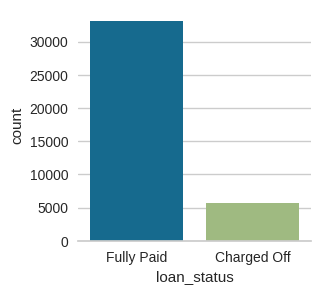

In [21]:
plot_countplot(lending_club_ds,'loan_status')

Loan status has two unique values,binary encoding can be used. And this is the Target variable.
  - The dataset is highly imbalanced, with the majority of the target variable y being "Fully Paid" (33,136 instances), compared to "Charged Off" (5,634 instances).
  - Approximately 85.5% of the entries are "Fully Paid" and only 14.5% are "Charged Off"
  - This imbalance suggests that the dataset is dominated by Positive outcomes "Fully Paid", which could affect the performance of some machine learning models if not addressed.

In [22]:
# For term
pd.concat(
    [
        lending_club_ds['term'].value_counts(),
        lending_club_ds['term'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
term,,
36 months,29096,0.750477
60 months,9674,0.249523


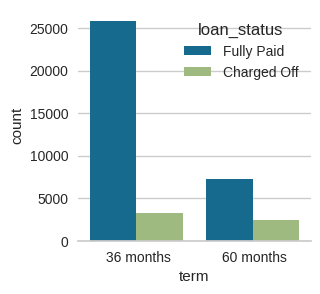

In [23]:
plot_countplot(lending_club_ds,'term')

This has the additional string "months", so need to be cleaned. Drop the "months" from the value. data is imbalanced

In [24]:
# For int_rate
pd.concat(
    [
        lending_club_ds['int_rate'].value_counts(),
        lending_club_ds['int_rate'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
int_rate,,
10.99%,928,0.023936
11.49%,795,0.020506
7.51%,787,0.020299
13.49%,760,0.019603
7.88%,725,0.018700
...,...,...
18.36%,1,0.000026
16.96%,1,0.000026
16.15%,1,0.000026


This is has the additional string "%", needs clean-up

In [25]:
# For grade
pd.concat(
    [
        lending_club_ds['grade'].value_counts(),
        lending_club_ds['grade'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
grade,,
B,11726,0.302450
A,10052,0.259273
C,7879,0.203224
D,5121,0.132087
E,2699,0.069616
F,992,0.025587
G,301,0.007764


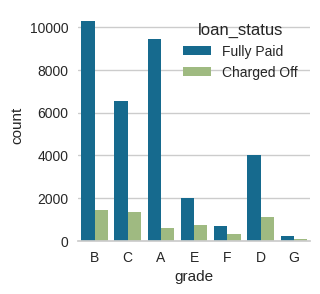

In [26]:
plot_countplot(lending_club_ds,'grade')

* By definition "Grade - LS assigned loan Grade", looking at value looks this is an ordinal data, so label encoding can be done.
* 'E','F','G' Grades normalized counts shows least influence, need to explore further.

In [27]:
# For sub_grade
pd.concat(
    [
        lending_club_ds['sub_grade'].value_counts(),
        lending_club_ds['sub_grade'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
sub_grade,,
A4,2874,0.074129
B3,2846,0.073407
A5,2721,0.070183
B5,2625,0.067707
B4,2447,0.063116
C1,2066,0.053289
B2,2008,0.051793
C2,1940,0.050039
A3,1810,0.046686


This appars to be sub category of `grade`, so sub_grade can be dropped,
let me do statistical data analysis 'Chi-Square Test' and 'Cramér's V' and check how this is influencing.Otherwise one-hot encoding, followed by PCA, and then use k-best or the best models feature selection.
Sub grades shows, 'F' and 'G' grade may not have any influence, need to explore further.

In [28]:
# For emp_length
pd.concat(
    [
        lending_club_ds['emp_length'].value_counts(),
        lending_club_ds['emp_length'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
emp_length,,
10+ years,8547,0.226507
< 1 year,4527,0.119971
2 years,4308,0.114168
3 years,4026,0.106694
4 years,3362,0.089097
5 years,3209,0.085043
1 year,3183,0.084354
6 years,2181,0.057799
7 years,1718,0.045529


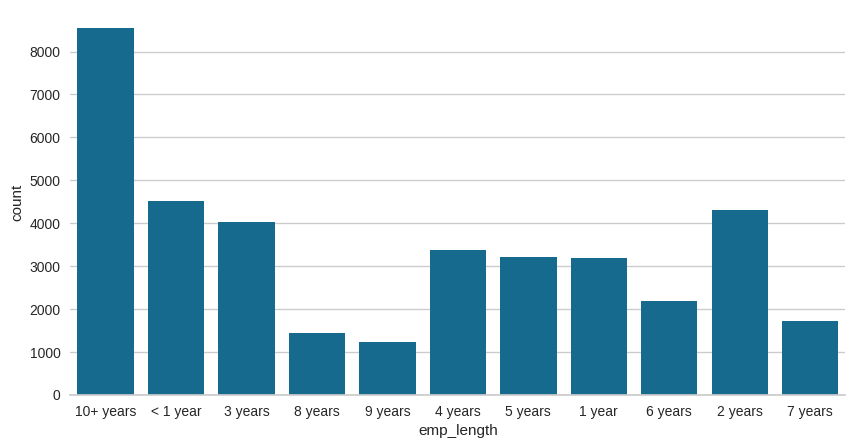

In [29]:
#plot_countplot(lending_club_ds,'emp_length')
plt.figure(figsize=(10,5))
sns.countplot(data=lending_club_ds,x=lending_club_ds['emp_length']) # Countplot is used as this being categorical feature
sns.despine(top=True,right=True,left=True) # to remove side line from graph

emp_length has the additional strings "+year", "<", and "years". Since there is No "10Years", 10+years means 10 years or more, so I can drop "+year". "<1year" - there is a "1year".  From the definition "Employment length in years. Possible values are between 0 and 10, where 0 means less than one year and 10 means ten or more years. so "< 1year" can be treated as "0.5".

In [30]:
# For homeowner_ship
pd.concat(
    [
        lending_club_ds['home_ownership'].value_counts(),
        lending_club_ds['home_ownership'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
home_ownership,,
RENT,18550,0.478463
MORTGAGE,17127,0.441759
OWN,2992,0.077173
OTHER,98,0.002528
NONE,3,0.000077


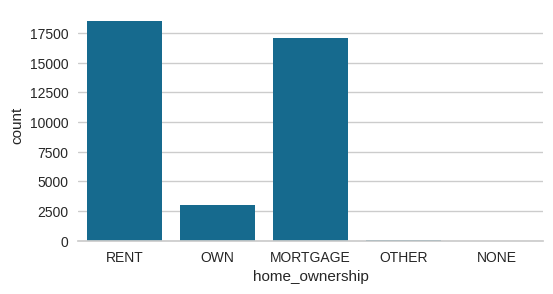

In [31]:
#plot_countplot(lending_club_ds,'home_ownership')
plt.figure(figsize=(6,3))
sns.countplot(data=lending_club_ds,x=lending_club_ds['home_ownership'])
sns.despine(top=True,right=True,left=True)

This is non-ordinal, so one-hot encoding can be used.
There is "none', Since there is no complete definition are available at this timeframe, and is only 3 count. I will keep this as another home ownership type and allow model to learn.

In [32]:
# For verification_status
pd.concat(
    [
        lending_club_ds['verification_status'].value_counts(),
        lending_club_ds['verification_status'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
verification_status,,
Not Verified,16732,0.431571
Verified,12301,0.317281
Source Verified,9737,0.251148


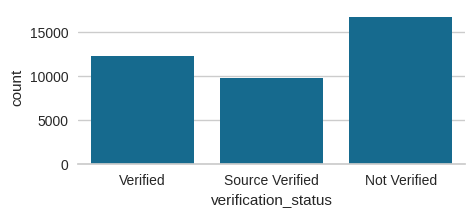

In [33]:
#plot_countplot(lending_club_ds,'verification_status')
plt.figure(figsize=(5,2))
sns.countplot(data=lending_club_ds,x=lending_club_ds['verification_status'])
sns.despine(top=True,right=True,left=True)

This is non-ordinal, so one-hot encoding can be used.

In [34]:
# For purpose
pd.concat(
    [
        lending_club_ds['purpose'].value_counts(),
        lending_club_ds['purpose'].value_counts(normalize=True)
    ],
    keys=['counts', 'normalized_counts'],
    axis=1,
)

,counts,normalized_counts
purpose,,
debt_consolidation,18145,0.468017
credit_card,5042,0.130049
other,3880,0.100077
home_improvement,2902,0.074852
major_purchase,2161,0.055739
small_business,1766,0.045551
car,1512,0.038999
wedding,930,0.023988
medical,682,0.017591


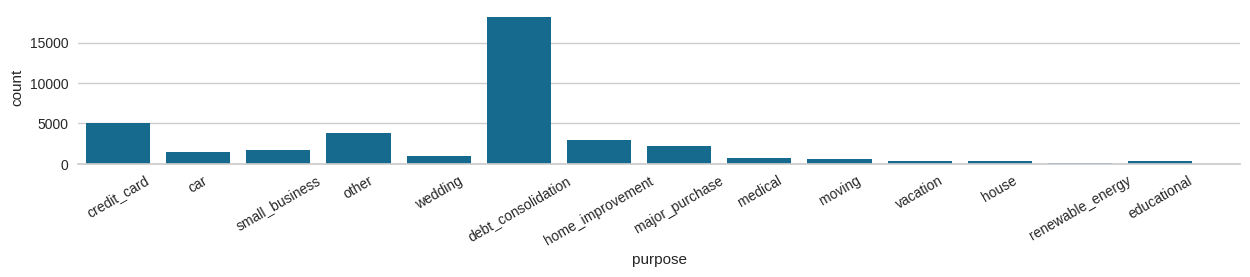

In [35]:
#plot_countplot(lending_club_ds,'purpose')
plt.figure(figsize=(15,2))
g = sns.countplot(data=lending_club_ds,x=lending_club_ds['purpose'])
sns.despine(top=True,right=True,left=True)
g.set_xticks(range(15))
plt.xticks(rotation=30)
plt.show()

The feature "purpose" has 14 unique values, one-hot encoding can be used, and later PCA and followed with K- best feature.

**Data cleaning**
* Copy of dataset is created with name "_new" attaching to original name, the new name is lending_club_ds_new.Original is kept untouched.
* Features int_rate,'revol_util,term,emp_length shall be cleaned for the additional strings.

In [36]:
# Function to plot the spread of data. Plots are box plot and histplot
def Plot_Spread(df,col_name):

    fig,(ax_box,ax_dis)  =plt.subplots(nrows=2,sharex=True,gridspec_kw = {"height_ratios": (.25, .75)},figsize=(5, 3))

    sns.set_theme(style="white")
    fig.suptitle("Spread of data for "+ col_name  , fontsize=10, fontweight='normal')
    fig.tight_layout()
    ax = sns.histplot(x=df[col_name], bins=8,color='blue',kde=True)
    sns.boxplot(x=df[col_name],showmeans=True, orient='h',color="violet",ax=ax_box)
    plt.xlabel(col_name,fontsize=10)
    plt.ylabel('Frequency',fontsize=10)
    plt.grid(False)
    plt.xticks(rotation=30)

    # Add a legend
    plt.legend()
    plt.show()

In [37]:
# creating the copy of lending_club_ds
lending_club_ds_new = lending_club_ds.copy()

In [38]:
# Clean 'int_rate' percentage and Convert columns to numeric and save as int_rate_cleaned
lending_club_ds_new['int_rate'] = lending_club_ds['int_rate'].str.rstrip('%').astype('float') / 100

# Clean 'revol_util' percentage and Convert columns to numeric and save as revol_util_cleaned
#lending_club_ds_new["revol_util_cleaned"] = lending_club_ds["revol_util"].str.rstrip('\n')
lending_club_ds_new['revol_util'] = lending_club_ds['revol_util'].str.rstrip('%').astype('float') / 100

# Clean "term" months and Convert column to numeric and save as term_cleaned
lending_club_ds_new['term'] = lending_club_ds['term'].str.rstrip('months').astype('int')

# Clean and Convert "+ years", "<","years" columns to numeric - emp_length_cleaned
emp_length = {'10+ years':10,'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,'5 years':0,'6 years':6,'7 years':7,'8 years':8,'9 years':9}
lending_club_ds_new['emp_length']=lending_club_ds['emp_length'].map(emp_length)

Since the data are converted to int or float datatypes, and no error , means all additional strings are dropped and data is cleaned interms of additional, extra string values.

In [39]:
# check the data for data clean
lending_club_ds_new.head()

,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,loan_status
0,1077501,1296599.0,5000.0,36,0.1065,162.87,B,B2,10.0,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,3.0,0.0,13648.0,0.837,9.0,171.62,Fully Paid
1,1077430,1314167.0,2500.0,60,0.1527,59.83,C,C4,0.0,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,3.0,0.0,1687.0,0.094,4.0,119.66,Charged Off
2,1077175,1313524.0,2400.0,36,0.1596,84.33,C,C5,10.0,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,2.0,0.0,2956.0,0.985,10.0,649.91,Fully Paid
3,1076863,1277178.0,10000.0,36,0.1349,339.31,C,C1,10.0,RENT,49200.0,Source Verified,other,20.00,0.0,1.0,10.0,0.0,5598.0,0.210,37.0,357.48,Fully Paid
4,1075269,1311441.0,5000.0,36,0.0790,156.46,A,A4,3.0,RENT,36000.0,Source Verified,wedding,11.20,0.0,3.0,9.0,0.0,7963.0,0.283,12.0,161.03,Fully Paid


##### **Missing value treatment**

Two features emp_length and revol_util are found be having null values.

In [40]:
print(f"Missing values for emp_length: {lending_club_ds_new['emp_length'].isnull().sum()} \nMissing values for revol_util:{lending_club_ds_new['revol_util'].isnull().sum()}")

Missing values for emp_length: 1036 
Missing values for revol_util:50


**Check for the emp_length distrbution and has the outliers**

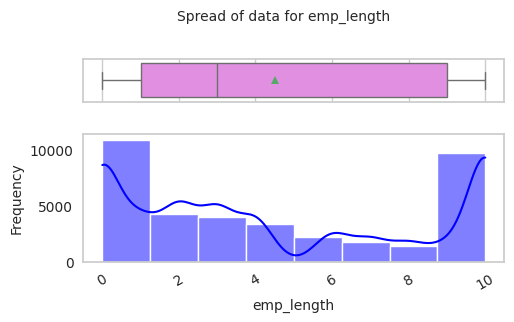

In [41]:
Plot_Spread(lending_club_ds_new,"emp_length")

'emp_length' has less missing values and no outliers found,and likely a bimodal distribution,using KNNImputer (K-Nearest Neighbors).
KNNImputer is an imputation technique that fills in missing values based on the nearest neighbors' values.
* Finds the K nearest rows (samples) that are closest to the missing value.
* Computes a weighted average (or majority vote for categorical data).
* Fills in the missing value with this computed value.

In [42]:
# Apply KNN Imputer
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3)
#impute the data
imputed_data = imputer.fit_transform(lending_club_ds_new[['emp_length']])
lending_club_ds_new['emp_length'] = pd.DataFrame(imputed_data, columns=['emp_length'])
# Check for missing value
print(f"Missing values for emp_length:{lending_club_ds_new['emp_length'].isnull().sum()}")

Missing values for emp_length:0


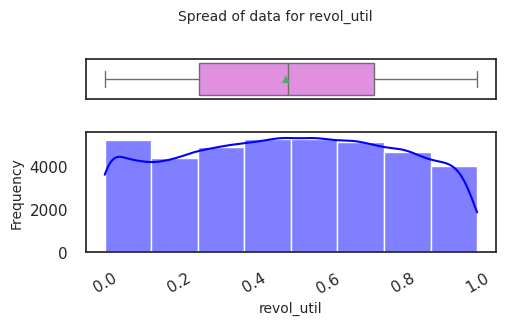

In [43]:
Plot_Spread(lending_club_ds_new,'revol_util')

'revol_util' has less missing values, and is uniformly distributed,median can be good choice. so using 'median' to fill the missing values

In [44]:
lending_club_ds_new.fillna(lending_club_ds_new['revol_util'].median(), inplace=True)

print(f"Missing values for revol_util:{lending_club_ds_new['revol_util'].isnull().sum()}")

Missing values for revol_util:0


**No more missing values**

##### **Check for Duplicates**

In [45]:
# Check for duplicates
duplicates = lending_club_ds_new.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


##### Observations **No Duplicates found**

##### **Datatype conversions**

In [46]:
## from the definition `grade`,'subgrade','home_ownership','verification_status','purpose' are changed to category datatype
lending_club_ds_new['grade'] = lending_club_ds_new['grade'].astype('category')
lending_club_ds_new['sub_grade'] = lending_club_ds_new['sub_grade'].astype('category')
lending_club_ds_new['home_ownership'] = lending_club_ds_new['home_ownership'].astype('category')
lending_club_ds_new['verification_status'] = lending_club_ds_new['verification_status'].astype('category')
lending_club_ds_new['purpose'] = lending_club_ds_new['purpose'].astype('category')

#from the definition 'emp_length','delinq_2yrs','inq_last_6mths','inq_last_6mths','open_acc','pub_rec' are need to be changed to int datatype
lending_club_ds_new['emp_length'] = lending_club_ds_new['emp_length'].astype('int32')
lending_club_ds_new['delinq_2yrs'] = lending_club_ds_new['delinq_2yrs'].astype('int32')
lending_club_ds_new['inq_last_6mths'] = lending_club_ds_new['inq_last_6mths'].astype('int32')
lending_club_ds_new['open_acc'] = lending_club_ds_new['open_acc'].astype('int32')
lending_club_ds_new['pub_rec'] = lending_club_ds_new['pub_rec'].astype('int32')

##### **Dropping the unnecessary columns**

- Columns which are not required for analysis - `id`, `member_id`
- Columns which are not available at the time of loan approval - `installment` and `last_pymnt_amnt`
- `grade` has the sub category `sub_grade`, let me use the statistical methods that measure the association between categorical data. 'Chi-Square Test of Independence' and 'Cramér's V (Strength of Association)' both together is used to find the how much knowing one variable reduces uncertainty about the other.

**Chi-Square Test and Cramér's V**
To check the correlation between `grade` and `sub_subgrade` which are categorical variables, Chi-Square Test and Cramér's V statistical methods shall be used to measure the association between categorical data.
Chi-Square Test of Independence : This test determines whether there is a significant association between two categorical variables.
Cramér's V (Strength of Association):Cramér's V helps measure the strength of association. With Cramér's V

    0 → No association: The two variables are completely independent (knowing one gives no information about the other).
    1 → Perfect association: Knowing one variable fully determines the other.
    Between 0 and 1 → Some level of association: Higher values indicate a stronger relationship.

In [47]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(lending_club_ds_new['grade'], lending_club_ds_new['sub_grade'])

# Perform chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

def cramers_v(chi2, n, k):
    return np.sqrt(chi2 / (n * (k - 1)))

n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape)  # Minimum dimension
cramers_v_value = cramers_v(chi2, n, min_dim)

print(f"Chi-Square Statistic: {chi2}, p-value: {p}")
print(f"Cramér's V: {cramers_v_value}")

Chi-Square Statistic: 232620.00000000003, p-value: 0.0
Cramér's V: 1.0


Cramér’s V = 1.0, this means there is a perfect association between the two categorical variables. This suggests that one variable is completely predictable from the other. This is supported with the p-value = 0 from the Chi-Square test,suggesting there is a strong dependence between the two categorical variables.
One column is redundant because it doesn't add new information.
one of them can be dropped without losing any information.
So droping column `grade` as `sub_grade` is more detailed.

In [48]:
## Drop the columns
#print(f"Total number of rows { lending_club_ds_new.shape[0]} and Total number of columns {lending_club_ds_new.shape[1]}")
print(f"After dropping:{lending_club_ds_new.shape}")
columns_toDrop = ['id','member_id','last_pymnt_amnt','installment','grade']
lending_club_ds_new = lending_club_ds_new.drop(columns = columns_toDrop)
print(f"After dropping:{lending_club_ds_new.shape}")

After dropping:(38770, 23)
After dropping:(38770, 18)


In [49]:
#Checking for cleaned data
lending_club_ds_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   loan_amnt            38770 non-null  float64 
 1   term                 38770 non-null  int64   
 2   int_rate             38770 non-null  float64 
 3   sub_grade            38770 non-null  category
 4   emp_length           38770 non-null  int32   
 5   home_ownership       38770 non-null  category
 6   annual_inc           38770 non-null  float64 
 7   verification_status  38770 non-null  category
 8   purpose              38770 non-null  category
 9   dti                  38770 non-null  float64 
 10  delinq_2yrs          38770 non-null  int32   
 11  inq_last_6mths       38770 non-null  int32   
 12  open_acc             38770 non-null  int32   
 13  pub_rec              38770 non-null  int32   
 14  revol_bal            38770 non-null  float64 
 15  revol_util         

In [50]:
lending_club_ds_new.describe(include= 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_amnt,38770.0,NaN,NaN,NaN,11069.122388,7362.2926,500.0,5325.0,9737.5,15000.0,35000.0
term,38770.0,NaN,NaN,NaN,41.988548,10.385818,36.0,36.0,36.0,36.0,60.0
int_rate,38770.0,NaN,NaN,NaN,0.119477,0.036979,0.0542,0.0894,0.1178,0.1442,0.2459
sub_grade,38770,35,A4,2874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_length,38770.0,NaN,NaN,NaN,4.505133,3.764781,0.0,1.0,4.0,9.0,10.0
home_ownership,38770,5,RENT,18550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_inc,38770.0,NaN,NaN,NaN,68800.25223,64161.315787,4000.0,40000.0,58923.5,82000.0,6000000.0
verification_status,38770,3,Not Verified,16732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,38770,14,debt_consolidation,18145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dti,38770.0,NaN,NaN,NaN,13.276704,6.676355,0.0,8.13,13.37,18.56,29.99


In [51]:
# Separate categorical and numerical features
categorical_features = lending_club_ds_new.select_dtypes(include=['object']).columns
numerical_features = lending_club_ds_new.select_dtypes(include=['number']).columns

##### **Identifying and Correcting Outliers**

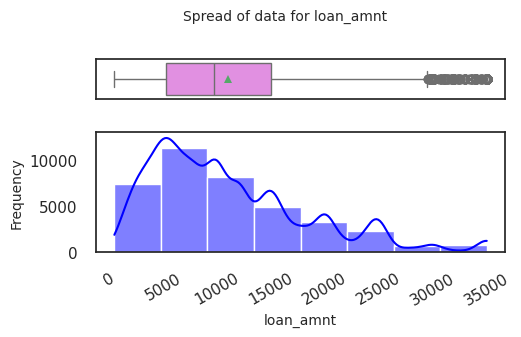

In [52]:
Plot_Spread(lending_club_ds_new,"loan_amnt")

loan amount is right skewed, and the spread is very wide, showing large outliers.These outlier should be brought into range, as this being loan amount, memebers may have those values

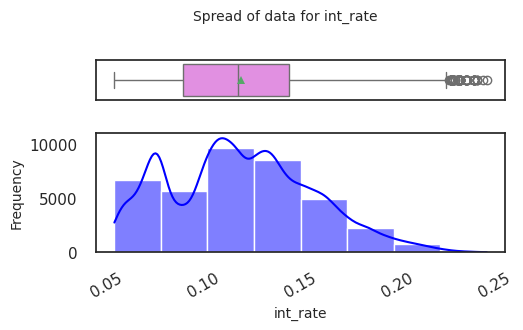

In [53]:
Plot_Spread(lending_club_ds_new,'int_rate')

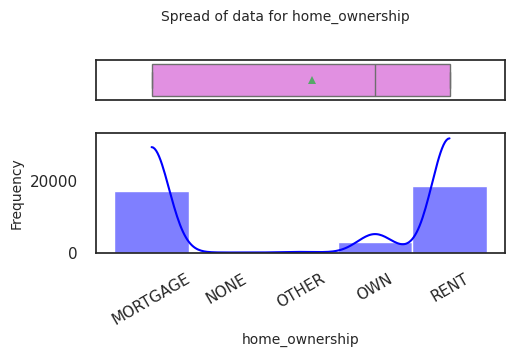

In [54]:
Plot_Spread(lending_club_ds_new,"home_ownership")

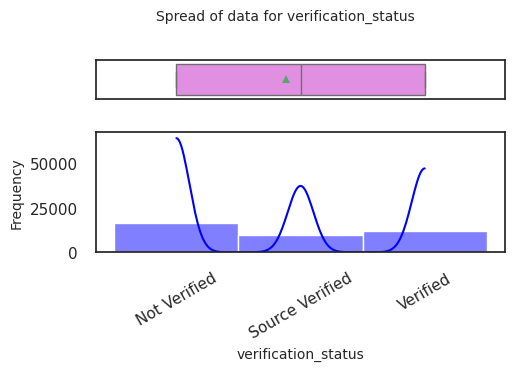

In [55]:
Plot_Spread(lending_club_ds_new,"verification_status")

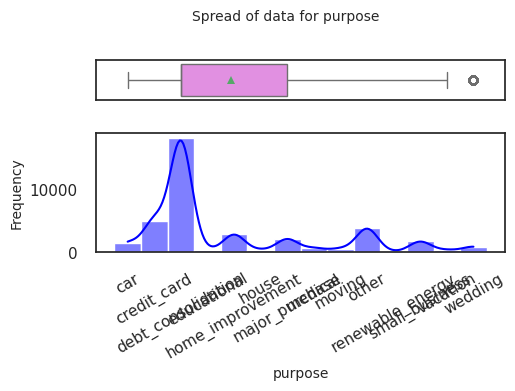

In [56]:
Plot_Spread(lending_club_ds_new,"purpose")

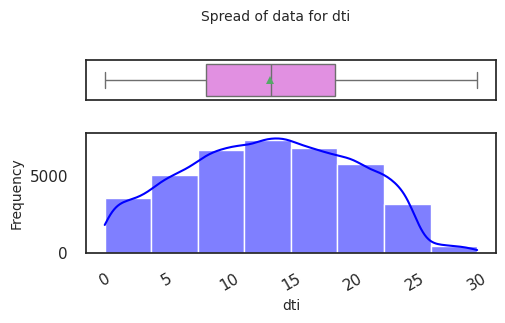

In [57]:
Plot_Spread(lending_club_ds_new,"dti")

datapoits are normaly distributed. no outliers or skeweness is seen.

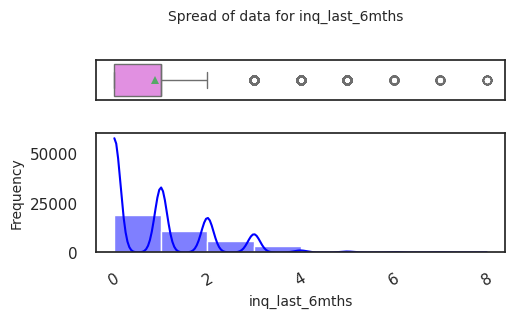

In [58]:
Plot_Spread(lending_club_ds_new,"inq_last_6mths")

More variability is visible as whisker length is long.suggesting data are widly spread with outliers

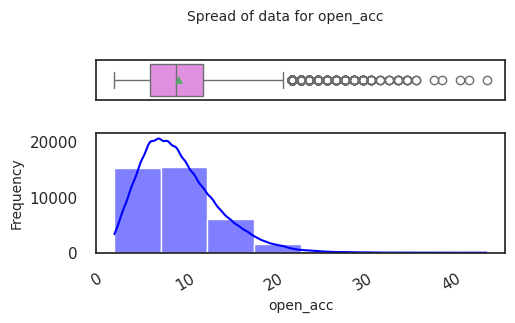

In [59]:
Plot_Spread(lending_club_ds_new,"open_acc")

More outliers are visible, and all appears to be genuine, and datapoits are right skewed.

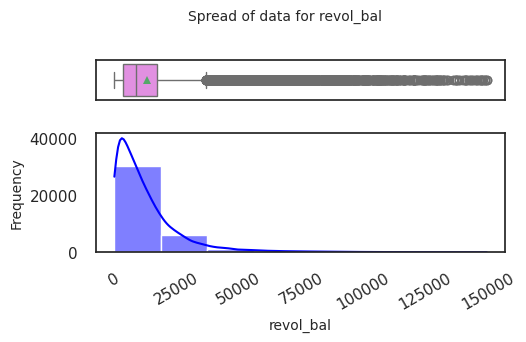

In [60]:
Plot_Spread(lending_club_ds_new,"revol_bal")

data is right skewed, and the spread is very wide, showing large outliers.However this is being revolving balance, memeber might have those balance, so outliers should be brought into range.

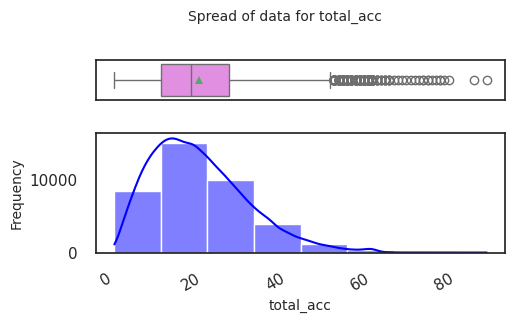

In [61]:
Plot_Spread(lending_club_ds_new,"total_acc")

data is right skewed and and no extreme low outliers, all the outliers are at high end and are clusterd.

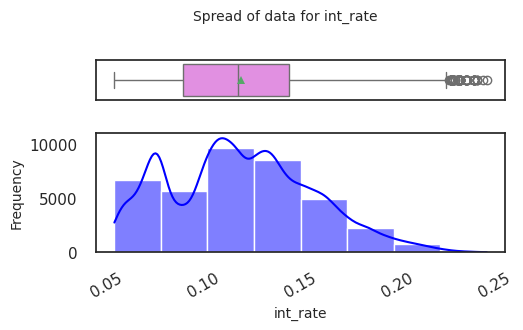

In [62]:
Plot_Spread(lending_club_ds_new,"int_rate")

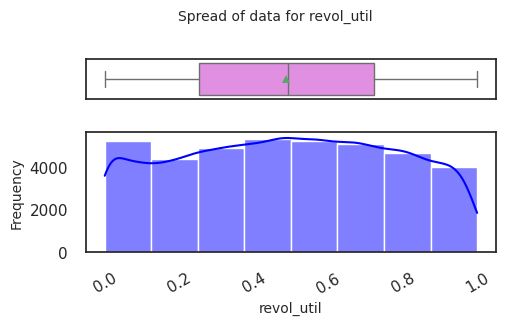

In [63]:
Plot_Spread(lending_club_ds_new,"revol_util")

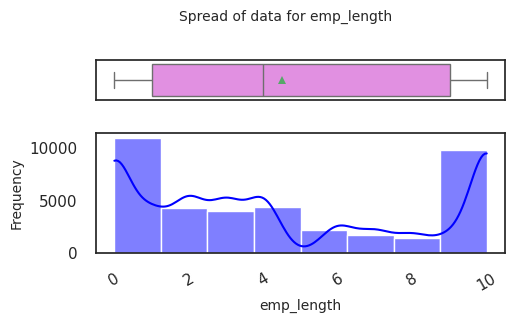

In [64]:
Plot_Spread(lending_club_ds_new,"emp_length")

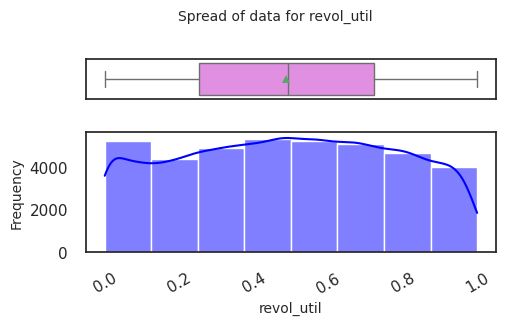

In [65]:
Plot_Spread(lending_club_ds_new,"revol_util")

####Interpretation
Most the features has the outliers, however these appears to be genuine and would like include most of these. so 'capping' treament can be done where most of the data are brought under the range.here are those features loan_amnt', int_rate', 'purpose', 'inq_last_6mths','open_acc', 'revol_bal', 'total_acc', 'int_rate'

#### **Outlier treatment**
**Capping**
- Capping prevents extreme outliers from creating noise that could lead to overfitting or underfitting.
- The model can still capture trends in the data without the noise created by extreme values
- Here 'Winsorization' capping technique us used.
Winsorization replaces extreme values with threshold values, preserving data points but reducing their impact.

some other common transformations are:

* Log Transformation: Helps to compress the range of values (especially useful when data has a right skew).
* Square Root Transformation: Reduces the impact of large outliers.
* Box-Cox Transformation: A more general method to stabilize variance and make the data more normal.

 #### Winsorization capping
 Winsorization does not remove data points; instead, it caps extreme values to the threshold  with 5th and 95th percentile.

In [66]:
from scipy.stats.mstats import winsorize

# Features with outliers
cols = ['loan_amnt', 'int_rate', 'inq_last_6mths','open_acc', 'revol_bal', 'total_acc', 'int_rate']

# 🔹 Compare min/max before and after Winsorization
print("Before Winsorization:")
print(lending_club_ds_new[cols].describe())

df = lending_club_ds_new[cols].copy()
for col in cols:
     df[col] = winsorize(df[col].values, limits=[0.05, 0.95])

# 🔹 Compare min/max before and after Winsorization
print("\nAfter Winsorization:")
print(lending_club_ds_new[cols].describe())

Before Winsorization:
          loan_amnt      int_rate  inq_last_6mths      open_acc  \
count  38770.000000  38770.000000    38770.000000  38770.000000   
mean   11069.122388      0.119477        0.871473      9.278850   
std     7362.292600      0.036979        1.071444      4.401871   
min      500.000000      0.054200        0.000000      2.000000   
25%     5325.000000      0.089400        0.000000      6.000000   
50%     9737.500000      0.117800        1.000000      9.000000   
75%    15000.000000      0.144200        1.000000     12.000000   
max    35000.000000      0.245900        8.000000     44.000000   

           revol_bal     total_acc      int_rate  
count   38770.000000  38770.000000  38770.000000  
mean    13297.262626     22.059788      0.119477  
std     15861.575434     11.420556      0.036979  
min         0.000000      2.000000      0.054200  
25%      3654.000000     13.000000      0.089400  
50%      8777.000000     20.000000      0.117800  
75%     16938.000

####Interpretatipn
Winsorization modifies extreme values, it doesn't remove them—it replaces them with a threshold value.As the  max/min limit are remaining same before and after Winsorization means outliers are still within the Winsorized range.

### Exploratory Data Analysis


#### Bivariate Analysis

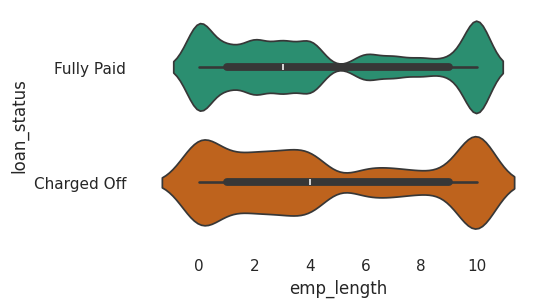

In [67]:
# Violin plot for emp_length vs loan_status by loan_status

plt.figure(figsize = (5, 3))
sns.violinplot(lending_club_ds_new, x='emp_length', y='loan_status', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

#### **Interpretation**
- Similar Distribution for fully paid and Charged off,employment length alone may not be a strong predictor of loan default.
-  Both groups have a high density of loans with shorter employment lengths (0–5 years).


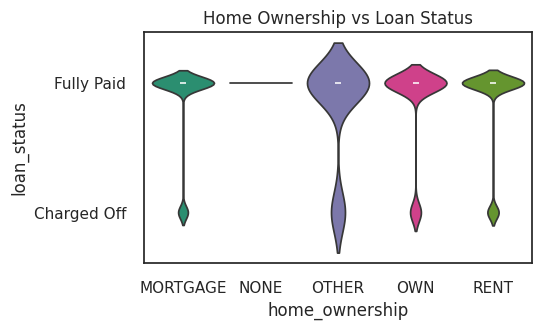

In [68]:
# Violin plot for home_ownership vs loan_status by loan_status
plt.figure(figsize=(5, 3))
sns.violinplot(x='home_ownership', y='loan_status', data=lending_club_ds_new, inner='box', palette='Dark2')
plt.title('Home Ownership vs Loan Status')
plt.show()


####**Interpretation**
- Memebers with `Other` home ownership are paid loan fully, in comparing to `rent`,`Mortage` and `own`
- With the same sense `other` are defaulted at returning the amount.

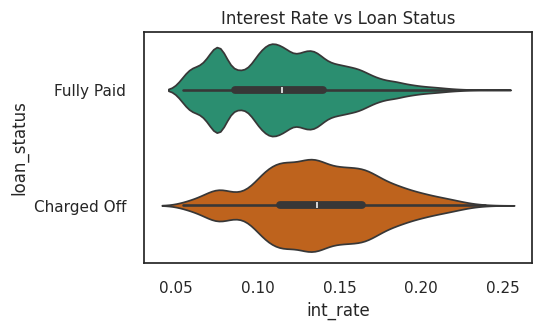

In [69]:
plt.figure(figsize=(5, 3))
sns.violinplot(x='int_rate', y='loan_status', data=lending_club_ds_new, inner='box', palette='Dark2')
plt.title('Interest Rate vs Loan Status')
plt.show()

####**Interpretation**
- Interest rate is as low as 0.05 and high 0.25
- Interest rate with 0.1 to 0.2 are more defauted in paying the amount.
- However Interest rate at around 0.6 and range 0.1 to 0.2 are paid amount fully.

"Charged Off" loans show a tendency toward higher interest rates, suggesting riskier profiles may be associated with higher costs.

"Fully Paid" loans seem to be more concentrated at lower interest rate ranges, indicating potentially safer lending criteria.

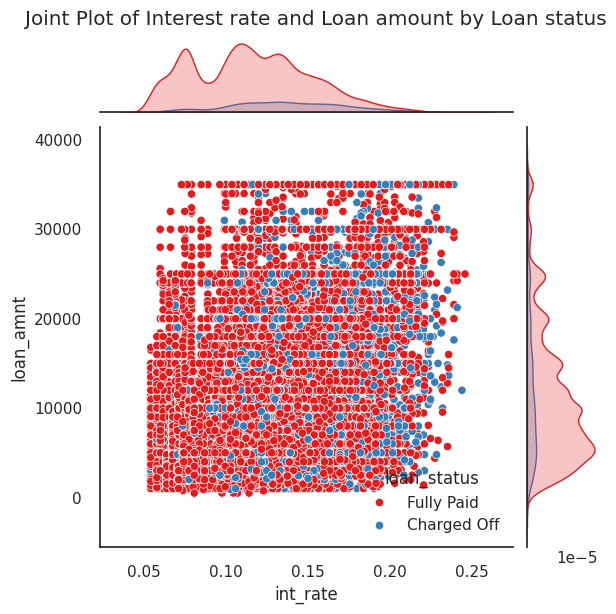

In [70]:
#Joint plot for interest rate, and loan amount against loan status
sns.jointplot(x='int_rate', y='loan_amnt', data=lending_club_ds_new, kind='scatter', hue='loan_status', palette='Set1')
plt.suptitle('Joint Plot of Interest rate and Loan amount by Loan status', y=1.02)
plt.show()

####**Interpretation**
- For low interest rates less members are defaulted, as interest rate goes up more memebers tend to be defaulted for payment
- Less memebers are taken high loan amount and defaulters are very less, looks they are fairly rich people.
- Memebers with medium loan amount ranging 10,000 to 15,000 are less defaulted in returning loan.
- looking at loan status spread, more people have taken lower loan amount and they are less interest rates.

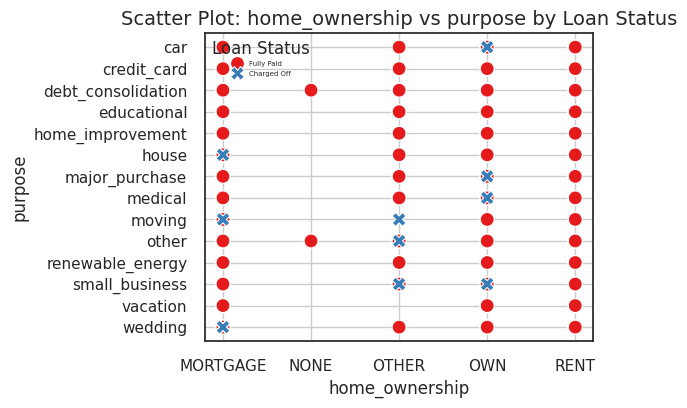

In [71]:
# Scatter Plot
# Create a scatter plot with color mapping by loan status
plt.figure(figsize=(5, 4))
sns.scatterplot(data=lending_club_ds_new, x='home_ownership', y='purpose', hue='loan_status', style='loan_status', palette='Set1', s=100)

# Customize plot
plt.title('Scatter Plot: home_ownership vs purpose by Loan Status', fontsize=14)
plt.xlabel('home_ownership', fontsize=12)
plt.ylabel('purpose', fontsize=12)
plt.legend(title='Loan Status', loc='upper left', fontsize=5)
plt.grid(True)

# Show the plot
plt.show()

#### **Interpretation**
- Members with rented house paid fully.
- Few members with mortgaged house are found be defaulters for wedding,house and moving purposes
- Few memebers whon owns the house are defaulted for small_bussiness,medical,car and miscellaneous reasons


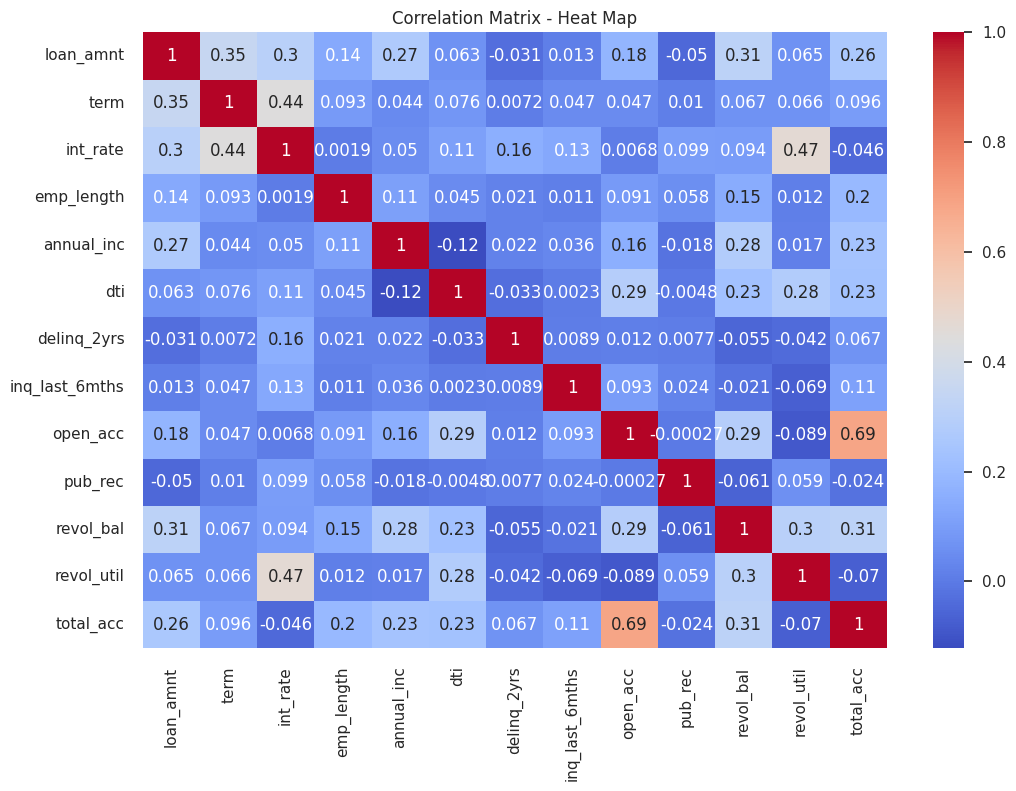

In [72]:
# Correlation matrix - Heat Map
plt.figure(figsize=(12, 8))

# Select only numerical columns for correlation matrix
numerical_cols = lending_club_ds_new.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Heat Map')
plt.show()

The following pairs of features show notable correlations:
* `open_acc` and `total_acc` have a moderate positive along correlation of 0.69, indicating open creditlines adds to total credit lines.
* `int_rate` and `revol_util` have a moderate positive correlation of 0.47, indicating Revolving line utilization rate -the amount of credit the borrower is using relative to all available revolving credit, shows the interest rate that member would be looking for, that is Interest rate on the loan.
* `loan_amnt` and `revol_bal` are moderatly correlated. Higher loan amounts may be associated with higher revolving balances.`
* `term` and `int_rate` are +ve correlated and correlation is moderate with 0.44, suggesting if the number of payments on the loan is more, interest rate are high.
* `loan_amnt` and `term`:Moderatly correlated with 0.35. Larger loans may be more likely to have longer terms.
* Weak negative coorelation can be seen between `total_acc` and `int_rate`,`revol_util`, indicating if total accounts goes up, interest rate and  amount of credit the borrower is using relative to all available revolving credit, slightly goes down.
* `pub_rec` has the weak negative coorelation with many, and those are  `annual_inc`,`loan_amt`,`dti`,`open_act`,`revol_bal` and `total_acc`, Derogatory public records has the -ve relation ship with annual income,loan amount,open account and revolving balance.
* Another weak -ve coorelation is seen between `delinq_2yrs` and `dti`,`revol_bal`,`revol_util`,this tells Number of 30+ days past-due incidences has the slight opposite relation with revolving balance and Revolving line utilization rate along with ratio calculated using the borrower’s total monthly debt payments, if `delinq_2yrs` goesup all these would reduce slightly.
   
- High debt-to-income ratio and revolving utilization could be indicators of financial risk.
- Open accounts and total accounts should be considered together when assessing creditworthiness.
-Since loan amount is positively correlated with term and interest rate, lenders might offer lower interest rates for shorter terms.
- Borrowers with high credit utilization and revolving balances might need tailored loan products to help manage their debt.

#### **Feature Engineering**

**Create new features based on highly correlated ones to avoid multicollinearity**

In [73]:
# 1. Total Pixel Resolution (`px_total`)
lending_club_ds_new['credit_lines'] = lending_club_ds_new['open_acc'] * lending_club_ds_new['total_acc']

# 2. Camera Quality Score (`cam_quality`)
lending_club_ds_new['credit_rate'] = lending_club_ds_new['int_rate'] + lending_club_ds_new['revol_util']

# Dropping the original features
lending_club_ds_new = lending_club_ds_new.drop(columns=['open_acc', 'total_acc', 'int_rate', 'revol_util'])

# Display the first few rows to check the new features
lending_club_ds_new.head()

,loan_amnt,term,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,pub_rec,revol_bal,loan_status,credit_lines,credit_rate
0,5000.0,36,B2,10,RENT,24000.0,Verified,credit_card,27.65,0,1,0,13648.0,Fully Paid,27.0,0.9435
1,2500.0,60,C4,0,RENT,30000.0,Source Verified,car,1.00,0,5,0,1687.0,Charged Off,12.0,0.2467
2,2400.0,36,C5,10,RENT,12252.0,Not Verified,small_business,8.72,0,2,0,2956.0,Fully Paid,20.0,1.1446
3,10000.0,36,C1,10,RENT,49200.0,Source Verified,other,20.00,0,1,0,5598.0,Fully Paid,370.0,0.3449
4,5000.0,36,A4,3,RENT,36000.0,Source Verified,wedding,11.20,0,3,0,7963.0,Fully Paid,108.0,0.3620


In [74]:
# The columns selelected for the modeling are
lending_club_ds_new.columns

Index(['loan_amnt', 'term', 'sub_grade', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'pub_rec', 'revol_bal', 'loan_status', 'credit_lines',
       'credit_rate'],
      dtype='object')

**Encoding on all the categorical variables**

Converting Categorical values to Numerical by applying binary encoding and one hot encoding.

In [75]:
# Converting categorical features (4 columns) to numerical using one-hot encoding
lending_club_ds_new = pd.get_dummies(lending_club_ds_new, columns=['sub_grade', 'home_ownership', 'verification_status','purpose'], drop_first=True)
# binary encoding loan_status
#Change loan_status to a 0/1 variable, where 0 indicates 'fully paid' and 1 indicates 'defaulter':
lending_club_ds_new['loan_status'] = lending_club_ds_new['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)

In [76]:
lending_club_ds_new.head()

,loan_amnt,term,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,pub_rec,revol_bal,loan_status,credit_lines,credit_rate,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,5000.0,36,10,24000.0,27.65,0,1,0,13648.0,0,27.0,0.9435,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False
1,2500.0,60,0,30000.0,1.00,0,5,0,1687.0,1,12.0,0.2467,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2400.0,36,10,12252.0,8.72,0,2,0,2956.0,0,20.0,1.1446,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,10000.0,36,10,49200.0,20.00,0,1,0,5598.0,0,370.0,0.3449,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,5000.0,36,3,36000.0,11.20,0,3,0,7963.0,0,108.0,0.3620,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [77]:
lending_club_ds_new.shape

(38770, 65)

In [78]:
# Visualizing the relationships using pair plot
#sns.pairplot(lending_club_ds_new, hue='loan_status', diag_kind='kde', markers=['o', 's'])
#plt.suptitle('Pair Plot of Lending Club Dataset', y=1.02)
#plt.show()

#### Pre-ML Data Pre-Processing

Before building the machine learning model, we shall perform
- Train-test split
- Scaling
- Handle class imbalance : This shall be done at various stages, after seeing the metrics

#### Split the data into train and test

 `train_test_split()` helps to split the data into training and test datasets and Stratifed train test split is used. Because dataset do not have a balanced number of examples for each class label so it is desirable to split the dataset into train and test sets that preserves the same proportions of examples in each class as observed in the original dataset.The stratify parameter ensures the training and testing samples have the same proportion of class values as the dataset provided.

In [79]:
from sklearn.model_selection import train_test_split
#Assuming X and y are features and target variable
# Split the data into 80% train and 20% test, stratifying by the target variable (y)
X = lending_club_ds_new.drop(['loan_status'],axis=1)
y = lending_club_ds_new['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1234)
# Display the shape of sets
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(31016, 64) (31016,) (7754, 64) (7754,)


#### **Scaling**
**MinMax Scaling**:  The Min-Max Scaler is a data normalization technique used to transform features so that they fit within a specific range, usually [0, 1]. This helps machine learning models train more effectively and obtain more generalized values for coefficients and intercepts.
Equation :  Xsc=X−Xmin/Xmax−Xmin where x is the datapoint. min and max are respective minimum and maximum values of corresponding datapoint

Since the outliers are capped, minmax scaling would be good form of scaling data,as nothing to cap by min max scalier.

In [80]:
# Apply MinMaxScaler to train and test data
from sklearn.preprocessing import MinMaxScaler

# Apply StandardScaler on train data (fit and transform)
MMscaler = MinMaxScaler(feature_range=(0, 1), copy=True, clip=False) # range is 0 to 1.
X_train = MMscaler.fit_transform(X_train)

# Apply the scaler on test data (transform only)
X_test = MMscaler.transform(X_test)

**Handling Class Imbalance**

Performing SMOTE: Handling imbalance data
This is an Imbalanced dataset .A problem with imbalanced classification is that there are too few examples of the minority class for a model to effectively learn the decision boundary.

One way to solve this problem is to oversample the examples in the minority class. This can be achieved by simply duplicating examples from the minority class in the training dataset prior to fitting a model. This can balance the class distribution but does not provide any additional information to the model.One approach to addressing imbalanced datasets is to oversample the minority class. The simplest approach involves duplicating examples in the minority class, although these examples don’t add any new information to the model. Instead, new examples can be synthesized from the existing examples. This is a type of data augmentation for the minority class and is referred to as the Synthetic Minority Oversampling Technique, or SMOTE for short.

As the target variable `loan_status` is categorical(fully paid and charged off) and is encoded to binary values 0 and 1, this leads to classification problem.so classification models
Logistic Regression, Decision Trees, Radom Forest and XGboost can be used.


**Choosing metrics**
* Predicting a potential defaulter(risky) as non-defaulter(safe borrower), i.e., False Negative,where is loan approved when it shouldn’t be
results in loss of revenue to the bank. This (FN) - Misclassifying Class 1 as Class 0

* However, predicting a non-defaulter(safe borrower) as defaulter(risky), i.e., False Positive, where loan is denied when it should be approved. This would lead for lost revenue opportunities and customer dissatisfaction. This (FP)- Misclassifying Class 0 as Class 1.

Here loss can be prevented by identifying good loans.So to prevent loss, Recall(catch more bad loans) need to increased, to identify good loan increase precision(reject less good borrowers)

Therefore, while recall is important, it should be balanced with precision too. Hence, Recall, along with F1 Score are good reliable metrics for the given problem statement.

* ROC-AUC and Precision-Recall Curve shall be plotted to get addtional insight.

* ROC-AUC Curve -The ROC-AUC curve is a graphical representation of a classifier's performance across different classification thresholds. It helps evaluate how well a model     distinguishes between classes.The x-axis represents the False Positive Rate (FPR).The y-axis represents the True Positive Rate (TPR).A perfect classifier has a curve that reaches (0,1) (i.e., TPR = 1 and FPR = 0), meaning perfect recall with no false positives.

    The higher the AUC, the better the performance of the model at distinguishing between the positive and negative classes.
    When AUC = 1, then the classifier is able to perfectly identified between all the Positive and the Negative class points correctly. If, however, the AUC had been 0, then the classifier would be predicting all Negatives as Positives, and all Positives as Negatives.he closer the curve is to the top-left corner, the better the model.
    The area under the ROC curve (AUC-ROC) quantifies performance:
    * AUC = 1.0 → Perfect classifier.
    * AUC = 0.5 → Random guessing (bad model).
    * AUC < 0.5 → Worse than random (model is predicting the wrong class more often than the right one).

* Precision-Recall Curve -
    The Precision-Recall (PR) Curve is a performance measurement tool used for evaluating classification models, particularly in imbalanced datasets where one class is significantly rarer than the other. It shows the trade-off between precision and recall at different classification thresholds.
    A classifier assigns a probability score to each instance.By setting different probability thresholds, different trade-offs between precision and recall are obtained.The PR curve plots precision against recall for these various thresholds.
    
    PR curves are better for imbalanced datasets, where the positive class is much rarer than the negative class.The Receiver Operating Characteristic (ROC) Curve may be misleading when there is class imbalance since it considers True Negatives, which can dominate performance metrics.PR Curve is better for imbalanced datasets, where the minority class is of higher interest.Higher AUC-PR is better.Closer to the Top-Right Corner: Indicates high precision and recall, representing better model performance.

In [81]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve,precision_recall_curve

In [1]:
# Calculate scores and report matrics
# create list to store scores to display in tabular form and is used at the end of the model
precision_recall_test = []
precision_recall_train = []

def Calculate_scores(model_name,y_test_df,y_pred_df,test = True):

    # Calculate Precision, Recall, and F1 Score, average=none is used to get both class scores
    precision = precision_score(y_test_df, y_pred_df,average=None)
    recall = recall_score(y_test_df, y_pred_df,average=None)
    f1 = f1_score(y_test_df, y_pred_df,average=None)
    #accuracy = accuracy_score(y_test,y_pred)

    # storing precision, reall, f1 score into list
    if test:
        precision_recall_test.append({
        'Model': model_name,
        'Precision_test': precision.round(2),
        'Recall_test': recall.round(2),
        'f1_test': f1.round(2)
        #'Accuracy': accuracy
        })
    else:
        precision_recall_train.append({
        'Model': model_name,
        'Precision_train': precision.round(2),
        'Recall_train': recall.round(2),
        'f1_train': f1.round(2)
        #'Accuracy': accuracy
        })


    # Calculate AUC (Area Under the ROC Curve)
    #roc_auc = roc_auc_score(y_test_df, y_pred_df)

    # Get confusion matrix and classification  report
    #conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test_df,y_pred_df)

    #print(f"\nConfusion matrix\n {conf_matrix}")
    print(f"\nClassification Report\n {class_report}")

In [83]:
# Confusion Matrix,Precision-Recall Curve, ROC Curve
def Plot_Reports(estimator,X_test_df,y_test_df,y_pred_df):
    y_pred_df = y_pred_df.astype(int)  # Ensure y_pred is integers

    # Convert y_test to integers if they are strings (in case this is needed)
    y_test_df = y_test_df.astype(int)
    # Set the style for the plots
    sns.set(style="whitegrid")

    # Create a figure with a larger size for better readability
    plt.figure(figsize=(12, 4))

    # 1. Confusion Matrix Heatmap
    plt.subplot(1, 3, 1)  # 1 row, 3 columns, first subplot
    cm = confusion_matrix(y_test_df, y_pred_df)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels = ["Non-defaulter","Defaulter"],yticklabels = ["Non-defaulter","Defaulter"])
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # 2. Precision-Recall Curve
    plt.subplot(1, 3, 2)  # 1 row, 3 columns, second subplot
    precision, recall, _ = precision_recall_curve(y_test_df, estimator.predict_proba(X_test_df)[:, 1])
    plt.plot(recall, precision, marker='o', color='teal',label=estimator)
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)

    # 3. ROC Curve
    plt.subplot(1, 3, 3)  # 1 row, 3 columns, third subplot
    fpr, tpr, _ = roc_curve(y_test_df, estimator.predict_proba(X_test_df)[:, 1])
    roc_auc = roc_auc_score(y_test_df, y_pred_df)
    plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc), color='orange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='red', alpha=0.7)
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

#### Logistic Regression Model
Logistic Regression is a supervised machine learning algorithm used for binary classification problems. Unlike linear regression, it predicts the probability of a class and maps the output to either 0 or 1 using a sigmoid function.By default, it uses threshold 0.5,  if the probability is greater than 0.5, classify as 1; otherwise, classify as 0.

*****Classification Report and Plots for Train Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.86      1.00      0.92     26509
           1       0.49      0.01      0.02      4507

    accuracy                           0.85     31016
   macro avg       0.67      0.50      0.47     31016
weighted avg       0.80      0.85      0.79     31016



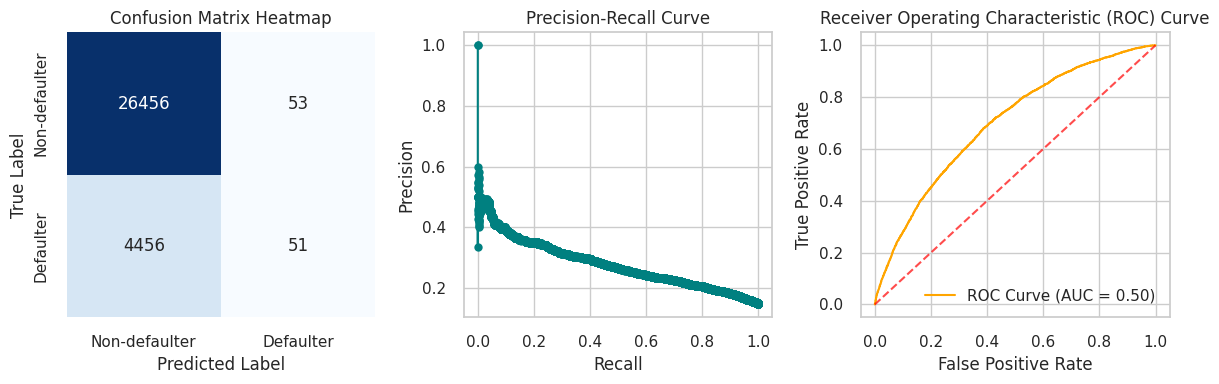

*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.86      1.00      0.92      6627
           1       0.65      0.01      0.02      1127

    accuracy                           0.86      7754
   macro avg       0.75      0.50      0.47      7754
weighted avg       0.83      0.86      0.79      7754



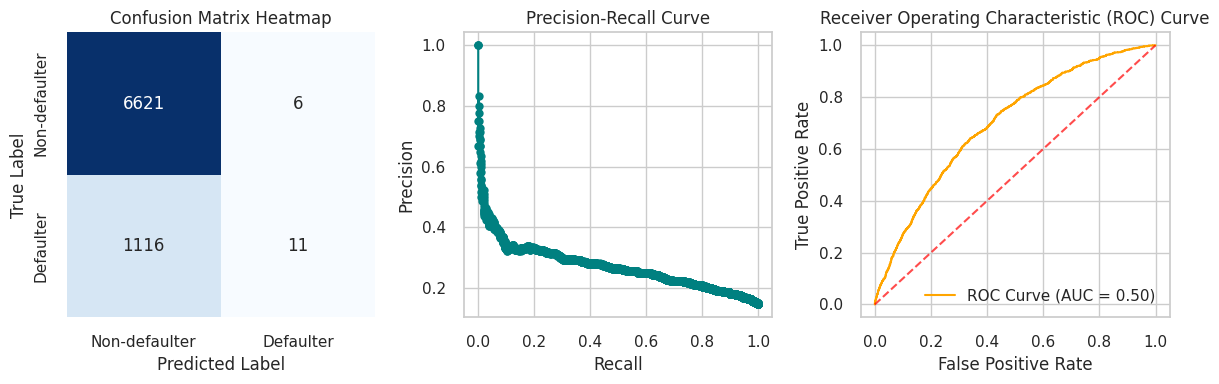

,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"


In [84]:
# Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=1234)
logistic_model.fit(X_train, y_train)

#---------------------------------------------
# Make predictions on Train set using the default threshold (0.5)
y_trainpred_lg = logistic_model.predict(X_train)

print("*****Classification Report and Plots for Train Dataset*****")
#Calculate Scores and Classification Report
Calculate_scores('LogisticRegression',y_train,y_trainpred_lg,False)

#Plot Reports
Plot_Reports(logistic_model,X_train,y_train,y_trainpred_lg)
#---------------------------------------------
# Make predictions on Test set using the default threshold (0.5)
y_testpred_lg = logistic_model.predict(X_test)

print("*****Classification Report and Plots for Test Dataset*****")
#Calculate Scores and Classification Report
Calculate_scores('LogisticRegression',y_test,y_testpred_lg,True)

#Plot Reports
Plot_Reports(logistic_model,X_test,y_test,y_testpred_lg)
#---------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')


####Interpretation
**For Train Dataset**

**Confusion Matrix**

- True Negatives (TN): 26,456 the number of non-default loans correctly identified as non-default.
- False Positives (FP): 53 the number of non-default loans incorrectly predicted as defaults.
- False Negatives (FN): 4,456 (the number of default loans incorrectly predicted as non-default.
- True Positives TP): 51 (the number of default loans correctly predicted as defaults.

**Precision:**
- Class 0 (non-defaulted loans): 0.86, which is strong, indicating the model is relatively good at correctly predicting non-default loans.
- Class 1 (defaulted loans): 0.49,This is relatively low and suggests the model is not very reliable when predicting defaults, with a relatively high number of false positives.

**Recall:**
- Class 0 (non-defaulted loans): 1.00, which means the model is very good at catching all non-defaulted loans.
- Class 1 (defaulted loans): 0.01, which is a very poor recall score. This suggests the model is missing almost all actual defaulted loans (high false negatives).

------------------------------------------
**For Test Dataset**
**Confusion Matrix**
- True Negatives (TN): 6,621, correctly predicted non-defaulted loans
- False Positives (FP): 6,non-defaulted loans incorrectly predicted as defaults
- False Negatives (FN): 1,116,defaulted loans incorrectly predicted as non-defaulted.
- True Positives (TP): 11,correctly predicted defaulted loans.

Lending Club might be exposed to significant financial risk by approving loans that will eventually default.

**Precision:**
- Class 0 (Non-Default) Precision = 0.86,When the model predicts a loan as non-default, it is correct 86% of the time.
- Class 1 (Default) Precision = 0.65,When the model predicts a default, it is correct only 65% of the time.

**Recall:**
- Class 0 (Non-Default) Recall = 1.00,The model correctly identifies all non-default loans.
- Class 1 (Default) Recall = 0.01,The model only correctly identifies 1% of actual defaults.
----------------------------------------------------------
**Precision-Recall Curve**
- Precision drops sharply as recall increases.
- Likely poor performance in minority class (1). This is predicting a non-defaulter(safe borrower) as defaulter(risky)

**ROC Curve & AUC Score**
- AUC = 0.50, which is random guessing.The model is not separating the classes well.
-----------------------------------------------
**Summary**

Class 1 Recall (0.01) - The Major Issue!The model misses 99% of actual defaulters, which is a huge problem for Lending Club. A low recall for defaults means that most risky loans are incorrectly approved, leading to potential financial losses.

Fixing recall should be the top priority, even if it slightly reduces precision
The model should prioritize catching more defaulters, even if it occasionally misclassifies a few good borrowers.

The significant class imbalance is evident, with many more non-default loans than default loans. This causes the model to be biased towards predicting non-default loans and makes it poor at identifying defaulted loans.Also model shows signs of overfitting.

 - To handle imbalance oversampling techniques (like SMOTE) can be used to increase the number of class 1 samples.Or do the Undersampling of majority class (class 0) to balance the dataset.
 - Class Weights: class weights can be adjusted to put more emphasis on class 1 by using the class_weight='balanced' parameter in your model
 - Potential overfitting is seen  looking at performance discrepancy between your training set and test set.This can be handled with Hyperparameter Tuning and/or Ensemble Method.



#### Logistic Regression with Optimal Threshold

By default, Logistic Regression uses a threshold of 0.5 to classify observations into 0 or 1. Since the dataset is found to be imbalanced,using 0.5 threshold might miss important cases.so adjust threshhold to balance recall & precision.By using precision_recall_curve optimal threshold shall be found, and used for actual prediction.

Optimal Threshold for train: 0.9424
*****Classification Report and Plots for Train Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.85      1.00      0.92     26509
           1       0.00      0.00      0.00      4507

    accuracy                           0.85     31016
   macro avg       0.43      0.50      0.46     31016
weighted avg       0.73      0.85      0.79     31016



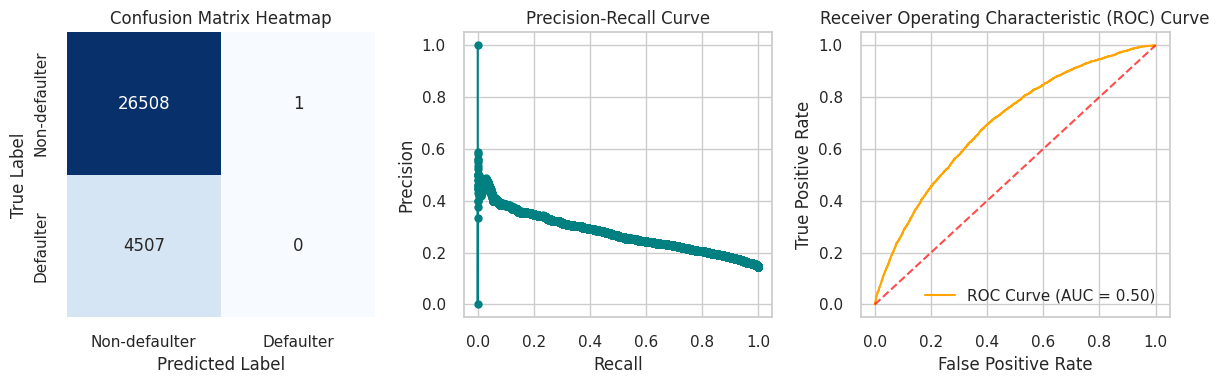

Optimal Threshold for train: 0.5234
*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      6627
           1       0.25      0.60      0.36      1127

    accuracy                           0.69      7754
   macro avg       0.58      0.65      0.57      7754
weighted avg       0.82      0.69      0.73      7754



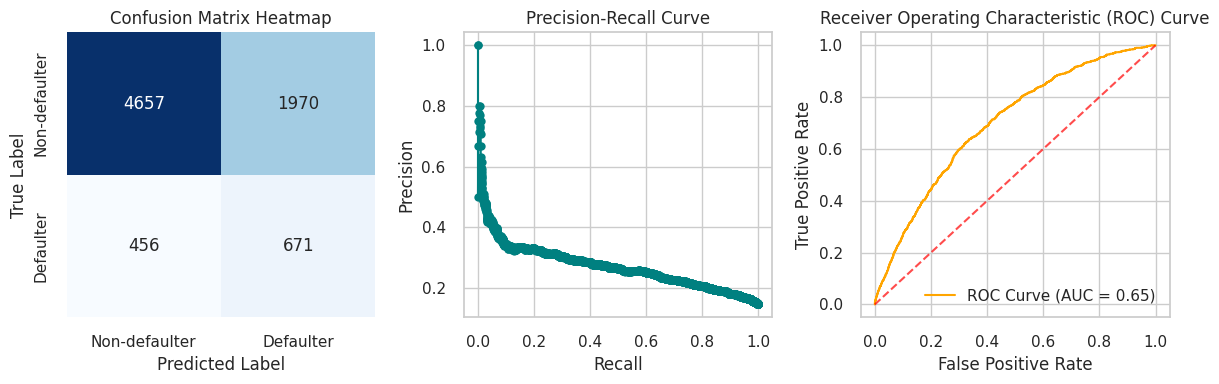

,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"
1,LogisticRegThreshold,"[0.91, 0.25]","[0.7, 0.6]","[0.79, 0.36]","[0.85, 0.0]","[1.0, 0.0]","[0.92, 0.0]"


In [85]:
# Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=1234, class_weight='balanced')
logistic_model.fit(X_train, y_train)

# Predict probabilities for the train set (to calculate AUC and ROC curve)
y_train_proba = logistic_model.predict_proba(X_train)[:, 1]

#Calculate precision, recall, and thresholds from precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_train, y_train_proba)

#Calculate F1-score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

#Find the threshold that maximizes the F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold for train: {optimal_threshold:.4f}")

# Make predictions using the optimal threshold
y_trainPred_lgOptimal = (y_train_proba >= optimal_threshold).astype(int)

print("*****Classification Report and Plots for Train Dataset*****")
#Calculate Scores and Classification Report
Calculate_scores('LogisticRegThreshold',y_train,y_trainPred_lgOptimal,False)

#Plot
Plot_Reports(logistic_model,X_train,y_train,y_trainPred_lgOptimal)

#--------------------------------------------------------------
# Predict probabilities for the test set (to calculate AUC and ROC curve)
y_test_proba = logistic_model.predict_proba(X_test)[:, 1]

#Calculate precision, recall, and thresholds from precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

#Calculate F1-score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

#Find the threshold that maximizes the F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold for train: {optimal_threshold:.4f}")

# Make predictions using the optimal threshold
y_testPred_lgOptimal = (y_test_proba >= optimal_threshold).astype(int)
#---------------------------------------------
print("*****Classification Report and Plots for Test Dataset*****")
#Calculate Scores and Classification Report
Calculate_scores('LogisticRegThreshold',y_test,y_testPred_lgOptimal,True)

#Plot
Plot_Reports(logistic_model,X_test,y_test,y_testPred_lgOptimal)
#---------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')

#### **Interpretation:**
With the threshold tuning here are the take aways -

**For Test Dataset**

**Classification Report**

- True Negatives (TN)  26,508 ,Correctly predicted class 0 (good loans).
- False Positives (FP)  1, Misclassified a class 0 as class 1.
- False Negatives (FN) 4,507,Misclassified a class 1 (bad loans) as class 0.
- True Positives (TP)  0,No bad loans were correctly predicted.

**Precision** for Class 1: 0.00 .Every time the model predicts a loan as bad, it's wrong.

**Recall** for Class 1 (defaulter): 0.00. The model is completely unable to identify bad loans.

**For Train Dataset**

**Classification Report**
- True Negatives (TN)  4,657 Correctly predicted good loans.
- False Positives (FP)  1,970 Good loans misclassified as bad.
- False Negatives (FN)  456 Bad loans misclassified as good.
- True Positives (TP)  671 Correctly predicted bad loans.

**Precision** Class 1 is still very low (25%), meaning many good loans are mistakenly classified as bad.

**Recall** Class 1 (Bad Loans) = 60% This is a big improvement over the initial model (which had 0% recall before).

-----------------------------------------------------------
**Precision-Recall Curve** -Precision drops sharply as recall increases. -This suggests that when the model tries to capture more positives (higher recall), it misclassifies a lot (low precision). -Likely poor performance in minority class (1), Same as Logistic regression.

**ROC Curve & AUC Score** -AUC = 0.65, slight improvement comparing with Logistic regression, but not significant.Model needs more improvement in doing classification.

----------------------------------------------------------
**Summary**

- The threshold 0.5234 likely increased recall for bad loans but at the cost of precision.
- False positives are still high (1,970 cases), meaning many good loans are flagged incorrectly.
- True positives improved (671 correctly identified bad loans), which is an improvement over Logistic Regression models that struggled with recall.
----------------------------------------------

### Random Forest Model with Balanced class weight
Random Forest is a powerful ensemble learning method that builds multiple decision trees and combines their predictions.
When using imbalanced datasets, models tend to favor the majority class, leading to poor recall and precision for the minority class.That is seen with Logistic regression. Since dataset is highly imbalanced, to address this we shall use class_weight='balanced' in settings.This automatically adjusts the weight of each class based on its frequency.

*****Classification Report and Plots for Train Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     26509
           1       1.00      0.95      0.97      4507

    accuracy                           0.99     31016
   macro avg       1.00      0.97      0.98     31016
weighted avg       0.99      0.99      0.99     31016



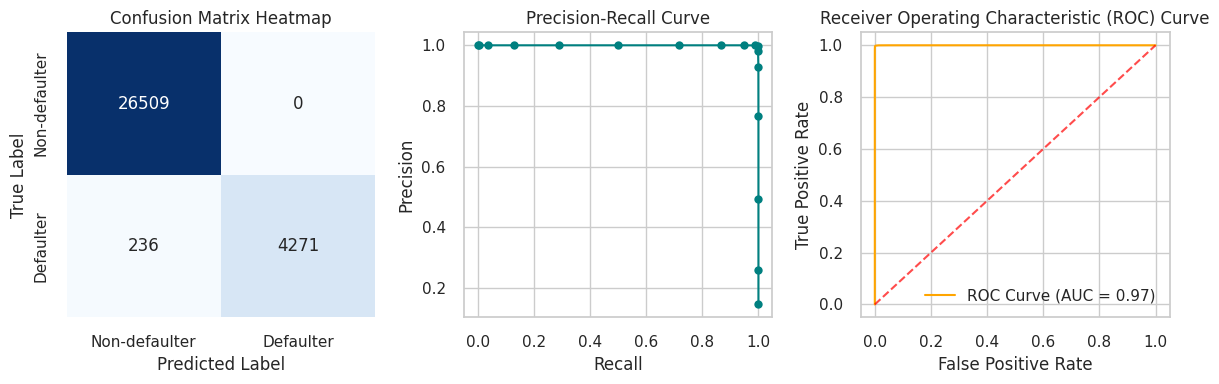

*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      6627
           1       0.34      0.02      0.04      1127

    accuracy                           0.85      7754
   macro avg       0.60      0.51      0.48      7754
weighted avg       0.78      0.85      0.79      7754



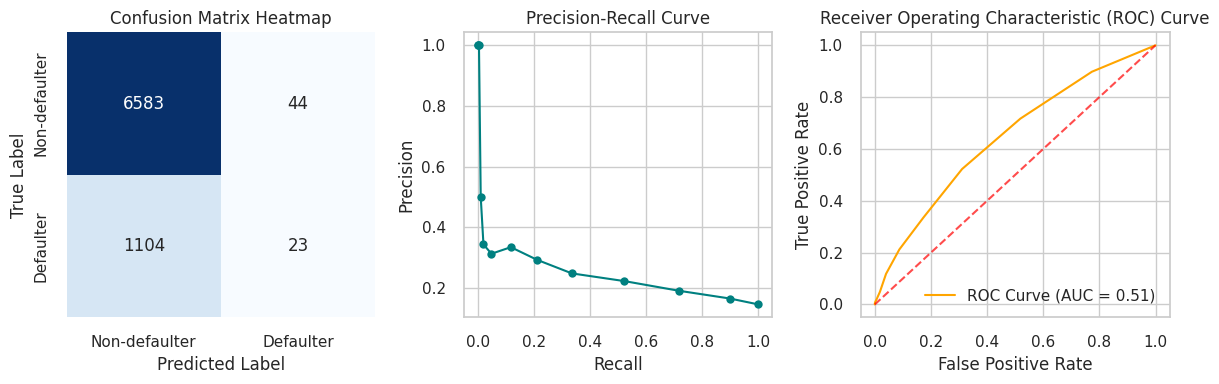

,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"
1,LogisticRegThreshold,"[0.91, 0.25]","[0.7, 0.6]","[0.79, 0.36]","[0.85, 0.0]","[1.0, 0.0]","[0.92, 0.0]"
2,RandomForest,"[0.86, 0.34]","[0.99, 0.02]","[0.92, 0.04]","[0.99, 1.0]","[1.0, 0.95]","[1.0, 0.97]"


In [86]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model with n_estimators=10
rf_model = RandomForestClassifier(n_estimators=15, random_state=1234, class_weight='balanced')
rf_model.fit(X_train, y_train)

#---------------------------------------------
# Make predictions on the training set
y_pred_rf_train = rf_model.predict(X_train)

print("*****Classification Report and Plots for Train Dataset*****")
#Calculate Scores and Classification Report for train dataset
Calculate_scores('RandomForest',y_train,y_pred_rf_train,False)

#Plot for train dataset
Plot_Reports(rf_model,X_train,y_train,y_pred_rf_train)
#---------------------------------------------
# Make predictions on the test set
y_pred_rf_test = rf_model.predict(X_test)

print("*****Classification Report and Plots for Test Dataset*****")
#Calculate Scores and Classification Report for test dataset
Calculate_scores('RandomForest',y_test,y_pred_rf_test,True)

#Plot for test dataset
Plot_Reports(rf_model,X_test,y_test,y_pred_rf_test)
#---------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')


####Interpretation
**For Train Dataset**

**Confusion Matrix**
- True Negatives (TN) 26,509,Loans correctly classified as low risk (0).
- False Positives (FP)  0, No loans misclassified as high risk that were actually low risk.
- False Negatives (FN) 236 -236 loans classified as low risk, but they were actually high risk.
- True Positives (TP)  4,271, Loans correctly classified as high risk (1).

**Precision** calss 1 (Defaulter) = 1.00: No false positives, meaning all loans predicted as high-risk were truly high-risk.

**Recall** class 1 (Defaulter) = 0.95: The model correctly identified 95% of actual high-risk loans, but missed 5% (236 FN).

**Precision-Recall Curve** A high area under the PR curve, the model correctly identifies mostdefaulter without many false alarms.

**ROC Curve & AUC Score** (0.5) can not discriminate between defaulter and non-defaulter.

------------------------------------------
**For Test Dataset**

**Confusion Matrix**
- True Negatives (TN)  6,583 Correctly classified as low-risk (0).
- False Positives (FP)  44 Low-risk loans misclassified as high-risk.
- False Negatives (FN) 1,104  High-risk loans incorrectly classified as low-risk.
- True Positives (TP)  23  Correctly classified as high-risk loans.

**Precision:** class 1 (Defaulter) = 0.34: Only 34% of loans predicted as high-risk were actually high-risk.

**Recall** class 1 (Defaulter) = 0.02: The model correctly identified only 2% of actual high-risk loans. This is extremely poor—almost all high-risk loans were misclassified as low-risk.

**F1-score** class 1 (Defaulter)  = 0.04: A very low score, indicating the model is struggling to balance precision and recall for this class.

**Precision-Recall Curve** A very low area under the PR curve due to the poor recall.

**ROC Curve & AUC Score** (0.51) showing poor separation ability for high-risk loans.

-----------------------------------------------
**Summary**
The recall for high-risk loans is only 2% on train data but 95% on test data, showing a huge gap.The model performs extremely well on test data but terribly on train data indicating **Severe Overfitting**
The model misses nearly all high-risk loans in training. A recall of 2% means the model is barely learning anything useful about high-risk loans.This suggests Poor High-Risk Loan Detection in Training.

### Random Forest Model with the following parameter Grid and Balanced class weight

This implementation includes hyperparameter tuning using GridSearchCV while ensuring class imbalance handling with class_weight='balanced'.GridSearchCV is a technique used for hyperparameter optimization, where all possible combinations of hyperparameters within a specified grid is tried to find the optimal set of hyperparameters for a model to improve performance.

Parameter Grid defines a dictionary containing the hyperparameters and their possible values.

Cross-Validation - GridSearchCV evaluates all combinations of the parameters through cross-validation (e.g., 5-fold, 10-fold).
class_weight used is 'balanced' in setting.
**param_grid:**

```
'n_estimators': [100,200],          
'max_depth': [10,20,30],        
'min_samples_split': [2,5,10]
```

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.93      0.75      0.83     26509
           1       0.31      0.66      0.42      4507

    accuracy                           0.74     31016
   macro avg       0.62      0.70      0.63     31016
weighted avg       0.84      0.74      0.77     31016



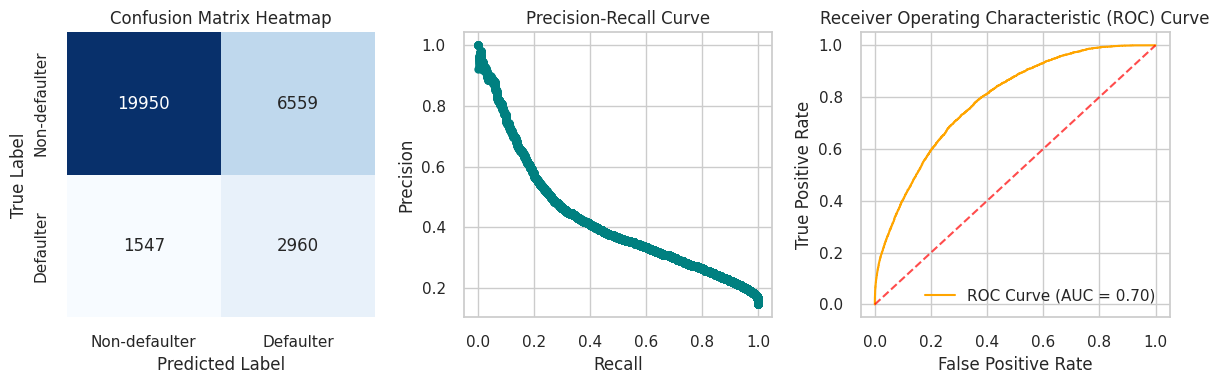

*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      6627
           1       0.26      0.53      0.35      1127

    accuracy                           0.72      7754
   macro avg       0.58      0.64      0.59      7754
weighted avg       0.81      0.72      0.75      7754



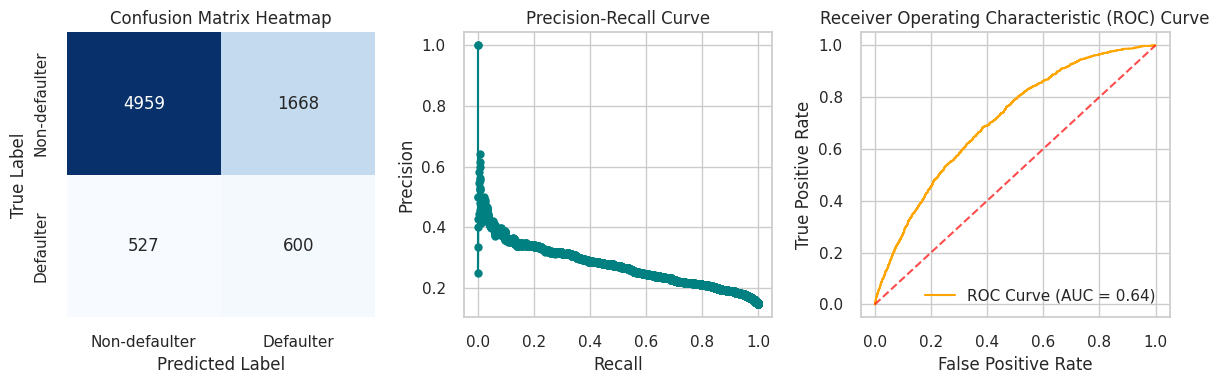

CPU times: user 16.4 s, sys: 1.17 s, total: 17.6 s
Wall time: 8min 44s


,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"
1,LogisticRegThreshold,"[0.91, 0.25]","[0.7, 0.6]","[0.79, 0.36]","[0.85, 0.0]","[1.0, 0.0]","[0.92, 0.0]"
2,RandomForest,"[0.86, 0.34]","[0.99, 0.02]","[0.92, 0.04]","[0.99, 1.0]","[1.0, 0.95]","[1.0, 0.97]"
3,RandomForestGS,"[0.9, 0.26]","[0.75, 0.53]","[0.82, 0.35]","[0.93, 0.31]","[0.75, 0.66]","[0.83, 0.42]"


In [87]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100,200],          # Number of trees
    'max_depth': [10, 20, 30],        # Maximum depth of each tree
    'min_samples_split': [2, 5, 10]         # Minimum samples required to split a node
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=1234, class_weight='balanced')

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,cv=5, scoring='f1', verbose=1, n_jobs=-1)

# Fit the GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

#-----------------------------------------------------------
# Make predictions on the test set using the best model
y_trainPred_rf_best = best_rf_model.predict(X_train)

print("*****Classification Report and Plots for Test Dataset*****")
#Calculate Scores and Classification Report for test dataset
Calculate_scores('RandomForestGS',y_train,y_trainPred_rf_best,False)

#Plot for test dataset
Plot_Reports(best_rf_model,X_train,y_train,y_trainPred_rf_best)
#-----------------------------------------------------------

# Make predictions on the test set using the best model
y_testPred_rf_best = best_rf_model.predict(X_test)

print("*****Classification Report and Plots for Test Dataset*****")

#Calculate Scores and Classification Report for test dataset
Calculate_scores('RandomForestGS',y_test,y_testPred_rf_best,True)

#Plot for test dataset
Plot_Reports(best_rf_model,X_test,y_test,y_testPred_rf_best)
#-----------------------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')

####Interpretation
**For Train Dataset**

**Confusion Matrix**
- True Negatives (TN) = 20274: Loans that were actually good (fully paid) and predicted correctly.
- False Positives (FP) = 6235: Loans that were actually bad (defaulted) but predicted as good—this is risky for Lending Club, as it means high credit risk exposure.
- False Negatives (FN) = 1584: Loans that were good but incorrectly classified as bad—a loss of potential revenue but safer than FP.
- True Positives (TP) = 2923: Loans that were bad (defaulted) and correctly identified.

**Precision** calss 1 (Defaulter) = 0.32 is Low. Many bad loans are misclassified as good, leading to high credit risk.

**Recall** class 1 (Defaulter) = 0.65: The model correctly identifies 65% of bad loans, which is decent but could be improved to reduce financial risk.

**f1-SCore**  = 0.63: Indicates the model does not perform well on minority class

**Precision-Recall Curve** Precision drops significantly as recall increase,low precision means a lot of false positives, which means the model is misclassifying defaulter as non-defaulter, that is risk for the company.

**ROC Curve & AUC Score** 0.71 indicating the model is better than random guessing but still not strong enough in distinguishing defaulter vs. non-defaulter.

------------------------------------------
**For Test Dataset**

**Confusion Matrix**
- True Negatives (TN) = 5018: Correctly classified good loans (fully paid).
- False Positives (FP) = 1609: Misclassified bad loans as good loans—a high - credit risk for Lending Club.
- False Negatives (FN) = 553: Misclassified good loans as bad, causing missed lending opportunities.
- True Positives (TP) = 574: Correctly identified bad loans (defaults).

**Precision:** class 1 (Defaulter)= 0.26 is low, meaning the model misclassifies many defaulter as non-defaulter, leading to high risk.

**Recall** class 1 (Defaulter)= 0.51 is moderate, meaning the model catches only half of the actual defaulters.

**Precision-Recall Curve** Drops very sharply,potential good customers are rejected. may be because of data imbalance.

**ROC Curve & AUC Score** = 0.63, slight improvement, but still struggles with bad loan detection.

-----------------------------------------------
**Summary**
False Positives (non-defaulter Classified as defaulter): High in both datasets, posing the risk of accepting high-risk loans. Lending Club approves a loan to someone who is likely to default on their payments.

False Negatives (defaulter Classified as non-defaulter): While not as severe as false positives, this still leads to missed opportunities for Lending Club to profit.


### XGBoost model
XGBoost (Extreme Gradient Boosting) is a highly efficient and powerful machine learning algorithm based on gradient boosting. It is known for its performance, scalability, and ability to handle both classification and regression tasks. This also has the built-in methods to calculate and visualize feature importance.

*****Classification Report and Plots for Train Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     26509
           1       0.97      0.28      0.44      4507

    accuracy                           0.89     31016
   macro avg       0.93      0.64      0.69     31016
weighted avg       0.90      0.89      0.87     31016



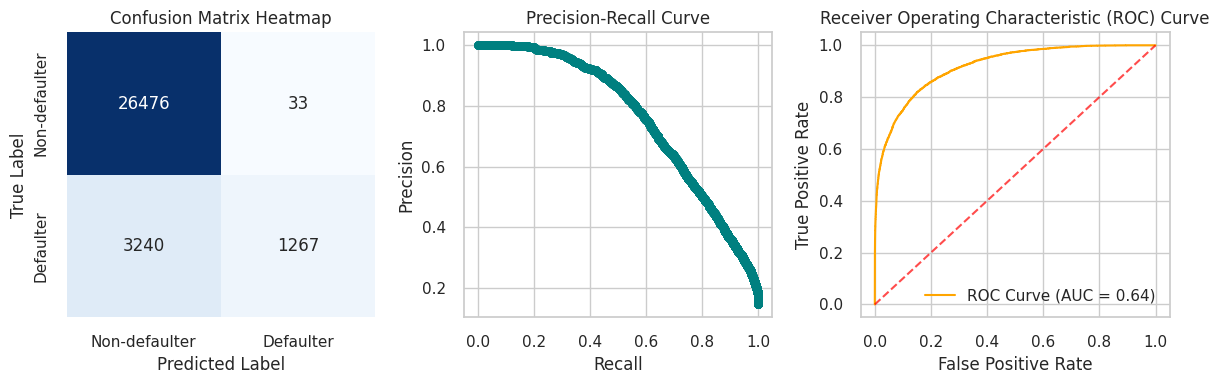

*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      6627
           1       0.41      0.06      0.10      1127

    accuracy                           0.85      7754
   macro avg       0.64      0.52      0.51      7754
weighted avg       0.80      0.85      0.80      7754



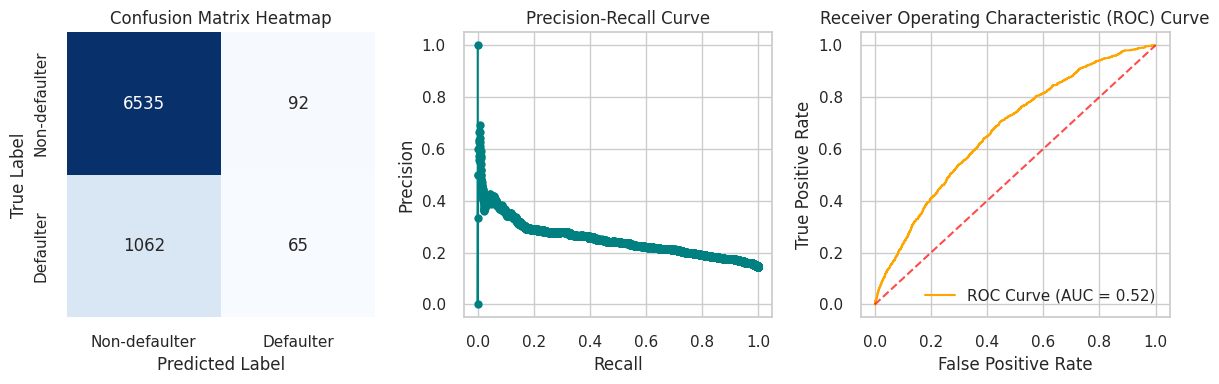

,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"
1,LogisticRegThreshold,"[0.91, 0.25]","[0.7, 0.6]","[0.79, 0.36]","[0.85, 0.0]","[1.0, 0.0]","[0.92, 0.0]"
2,RandomForest,"[0.86, 0.34]","[0.99, 0.02]","[0.92, 0.04]","[0.99, 1.0]","[1.0, 0.95]","[1.0, 0.97]"
3,RandomForestGS,"[0.9, 0.26]","[0.75, 0.53]","[0.82, 0.35]","[0.93, 0.31]","[0.75, 0.66]","[0.83, 0.42]"
4,XGBoost,"[0.86, 0.41]","[0.99, 0.06]","[0.92, 0.1]","[0.89, 0.97]","[1.0, 0.28]","[0.94, 0.44]"


In [88]:
import xgboost as xgb

# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=1234)

# Train the model
xgb_model.fit(X_train, y_train)
#--------------------------------------------
# Make predictions on the training set
y_pred_xgb_train = xgb_model.predict(X_train)

print("*****Classification Report and Plots for Train Dataset*****")
#Calculate Scores and Classification Report for train dataset
Calculate_scores('XGBoost',y_train,y_pred_xgb_train,False)

#Plot for train dataset
Plot_Reports(xgb_model,X_train,y_train,y_pred_xgb_train)

#--------------------------------------------
# Make predictions on the test set
y_pred_xgb_test = xgb_model.predict(X_test)

print("*****Classification Report and Plots for Test Dataset*****")
#Calculate Scores and Classification Report for test dataset
Calculate_scores('XGBoost',y_test,y_pred_xgb_test,True)

#Plot for test dataset
Plot_Reports(xgb_model,X_test,y_test,y_pred_xgb_test)
#--------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')

####Interpretation
**For Train Dataset**

**Confusion Matrix**
- True Negatives (TN)   26474: Loans that were actually good (fully paid) and predicted correctly.
- False Positives (FP)  33: Loans that were actually bad (defaulted) but predicted as good—this is risky for Lending Club, as it means high credit risk exposure.
- False Negatives (FN)  3240: Loans that were good but incorrectly classified as bad—a loss of potential revenue but safer than FP.
- True Positives (TP)  1267: Loans that were bad (defaulted) and correctly identified.

**Precision** calss 1 (Defaulter) = 0.97 meaning most prediction of default or non-default was correct.only 3% failed.

**Recall** class 1 (Defaulter) = 0. 0.28: The model only correctly identifies 28% of the actual Defaulter cases, which is very low.

**Precision-Recall Curve** Initially precision stayed high and  drops slowly as recall increase, which means the model is misclassifying defaulter as non-defaulter,after performing well at intial stage. plot shows of data imbalance.

**ROC Curve & AUC Score** 0.64 slightly better in seperating two classes.

------------------------------------------
**For Test Dataset**

**Confusion Matrix**
- True Negatives (TN) 6535: Correctly predicted "No Default".
- False Positives (FP)  92: Incorrectly predicted "Default" when the actual label was "No Default".
- False Negatives (FN)  1062: Missed "Default" instances.
- True Positives (TP)  65: Correctly predicted "Default".

**Precision:** class 1 (Defaulter)= 0.41: When the model predicts "Default", it’s correct 41% of the time.

**Recall** class 1 (Defaulter)= 0.06: The model only correctly identifies 6% of the actual Defaulter cases, which is very low.

**Precision-Recall Curve** Drops very sharply,potential good customers are rejected. may be because of data imbalance.

**ROC Curve & AUC Score** = 0.52, meaning it struggles with bad loan detection.

-----------------------------------------------
**Summary**
The model performs very well in predicting "No Default," achieving high precision and recall.The model struggles significantly with predicting "Default,There is overfitting as train metrics are better than test data netrics.


#### Feature Importance with XGBoost
Feature importance refers to the contribution of each feature (or variable) in predicting the target variable.

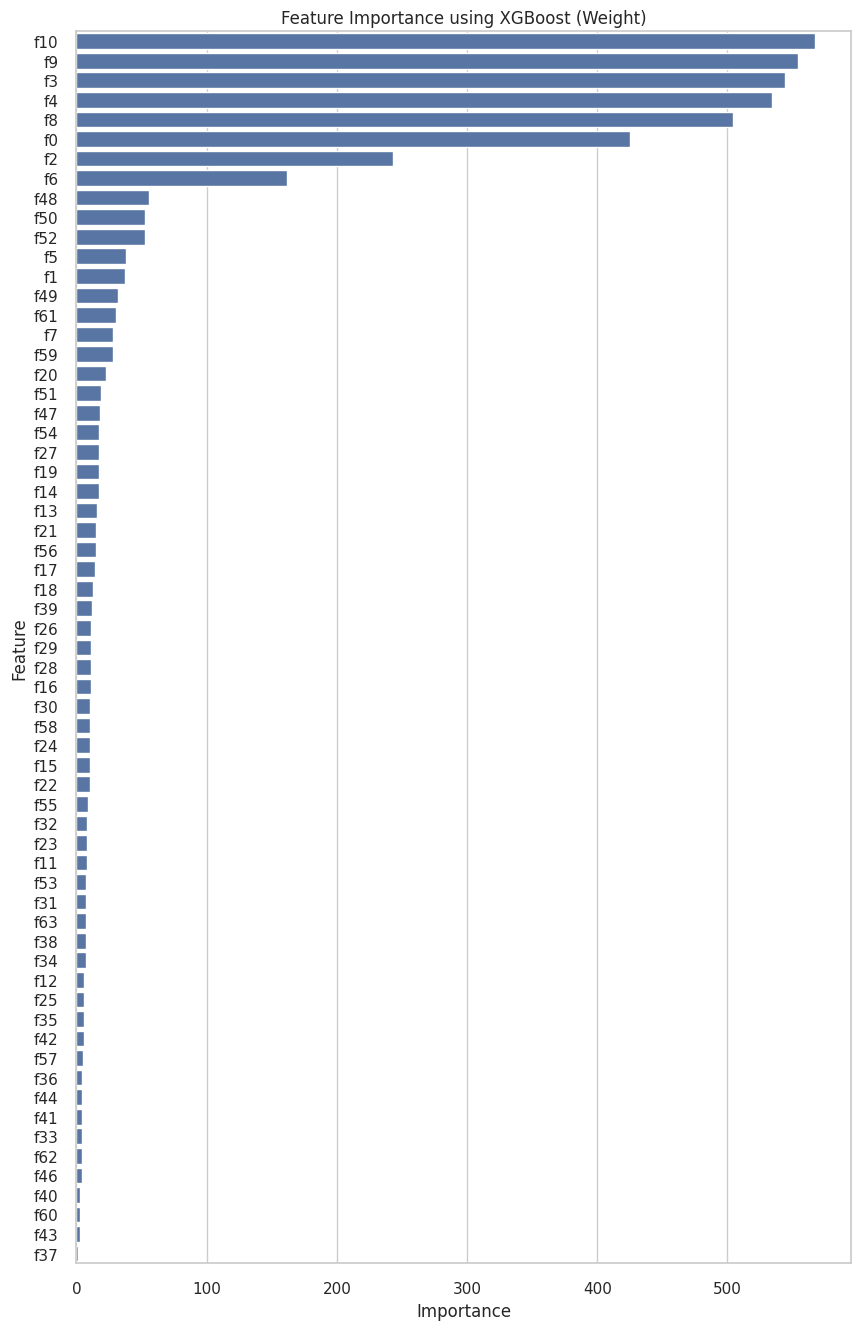

In [89]:
# Get feature importance using XGBoost's built-in method
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Convert to pandas DataFrame for better visualization
importance_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting Feature Importance
plt.figure(figsize=(10, 16))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance using XGBoost (Weight)')
plt.show()



From XGBoost Feature importance technique, the top 10 features are f10,f4,f3,f9,f8,f0,f2,f6,f50,f1

In [90]:
# the top 10 features from XGBoost from Feature importance technique
lending_club_ds_new.columns[[10, 4, 3,9,8,0,2,6,50,1]].tolist()

['credit_lines',
 'dti',
 'annual_inc',
 'loan_status',
 'revol_bal',
 'loan_amnt',
 'emp_length',
 'inq_last_6mths',
 'verification_status_Source Verified',
 'term']

### XGBoost model with hyper parameter tuning

Hyperparameter tuning allows to optimize the parameters of the XGBoost model for better performance. In this process RandomizedSearchCV shall be used to find the best combination of hyperparameters for the model.

RandomizedSearchCV is a method for hyperparameter tuning that randomly samples a subset of hyperparameters from a larger search space and evaluates the performance of the model using cross-validation.

eval_metric='logloss' paramete is used to specify the evaluation metric during training, as it is binary classification problem.Log Loss heavily penalizes incorrect predictions where the model is very confident and measures the performance with probability value between 0 and 1.

**Hyperparameter grid:**

    - 'n_estimators': [50, 100, 200, 300],                 
    - 'learning_rate': [0.01, 0.1, 0.2, 0.3],              
    - 'max_depth': [None, 3, 5, 7, 10],                          
    - 'min_child_weight': [1, 3, 5],                      
    - 'subsample': [0.2, 0.6, 0.8, 1.0],                        
    - 'colsample_bytree': [0.6, 0.8, 1.0],                 
    - 'gamma': [0, 0.1, 0.3, 0.5]

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.2, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.94      0.57      0.71     26509
           1       0.24      0.80      0.37      4507

    accuracy                           0.60     31016
   macro avg       0.59      0.68      0.54     31016
weighted avg       0.84      0.60      0.66     31016



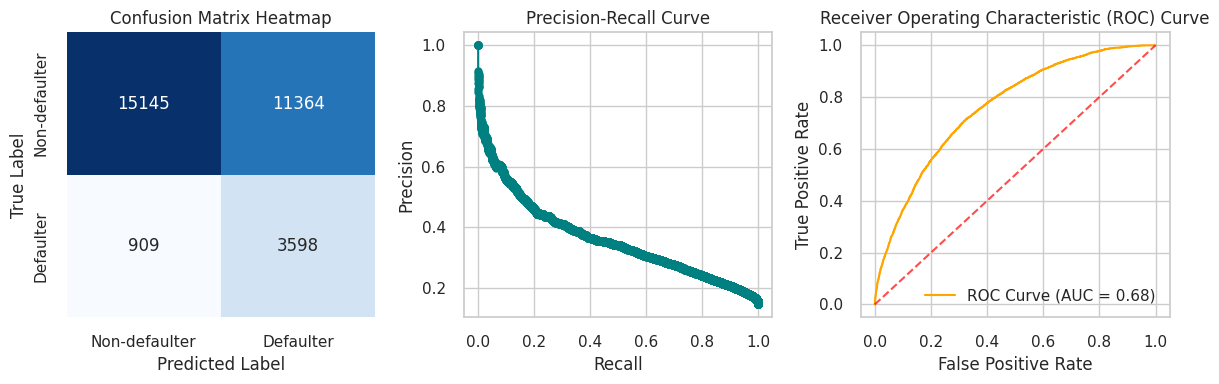

*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.92      0.57      0.71      6627
           1       0.22      0.72      0.34      1127

    accuracy                           0.59      7754
   macro avg       0.57      0.64      0.52      7754
weighted avg       0.82      0.59      0.65      7754



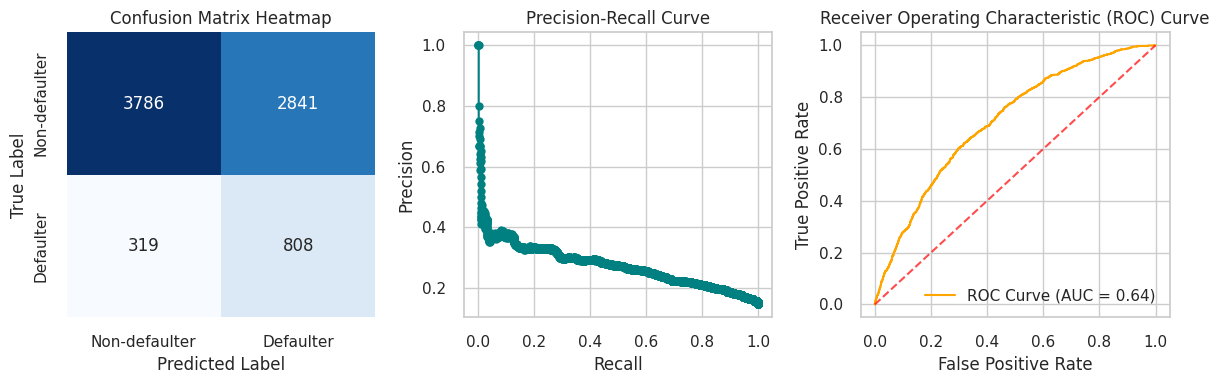

,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"
1,LogisticRegThreshold,"[0.91, 0.25]","[0.7, 0.6]","[0.79, 0.36]","[0.85, 0.0]","[1.0, 0.0]","[0.92, 0.0]"
2,RandomForest,"[0.86, 0.34]","[0.99, 0.02]","[0.92, 0.04]","[0.99, 1.0]","[1.0, 0.95]","[1.0, 0.97]"
3,RandomForestGS,"[0.9, 0.26]","[0.75, 0.53]","[0.82, 0.35]","[0.93, 0.31]","[0.75, 0.66]","[0.83, 0.42]"
4,XGBoost,"[0.86, 0.41]","[0.99, 0.06]","[0.92, 0.1]","[0.89, 0.97]","[1.0, 0.28]","[0.94, 0.44]"
5,xgboostRS,"[0.92, 0.22]","[0.57, 0.72]","[0.71, 0.34]","[0.94, 0.24]","[0.57, 0.8]","[0.71, 0.37]"


In [91]:
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],                 # Number of trees
    'learning_rate': [0.01, 0.1, 0.2, 0.3],              # Learning rate
    'max_depth': [None, 3, 5, 7, 10],                    # Maximum depth of each tree
    'min_child_weight': [1, 3, 5],                       # Minimum sum of instance weight (hessian) needed in a child
    'subsample': [0.2, 0.6, 0.8, 1.0],                   # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.8, 1.0],                 # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.3, 0.5]                          # Minimum loss reduction required to make a further partition on a leaf node
}

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=1234, use_label_encoder=False, scale_pos_weight=8, eval_metric='logloss')

# Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist,n_iter=50, scoring='f1', cv=5, verbose=1, n_jobs=-1, random_state=42)

# Fit the RandomizedSearchCV on the training data
random_search.fit(X_train, y_train)

#  Get the best parameters and best estimator
best_params = random_search.best_params_
best_xgb_model = random_search.best_estimator_

print(f"Best Parameters: {best_params}")
#-------------------------------------------------------
# Make predictions on the train set using the best model
y_trainPred_xgbhp_best = best_xgb_model.predict(X_train)

print("*****Classification Report and Plots for Test Dataset*****")

#Calculate Scores and Classification Report for test dataset
Calculate_scores('xgboostRS',y_train,y_trainPred_xgbhp_best,False)

#Plot for test dataset
Plot_Reports(best_xgb_model,X_train,y_train,y_trainPred_xgbhp_best)
#-------------------------------------------------------

# Make predictions on the test set using the best model
y_testPred_xgbhp_best = best_xgb_model.predict(X_test)

print("*****Classification Report and Plots for Test Dataset*****")

#Calculate Scores and Classification Report for test dataset
Calculate_scores('xgboostRS',y_test,y_testPred_xgbhp_best,True)

#Plot for test dataset
Plot_Reports(best_xgb_model,X_test,y_test,y_testPred_xgbhp_best)
#-------------------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')

####Interpretation
**For Train Dataset**

**Confusion Matrix**
- True Negative (TN) 15145: Correctly predicted non-defaulters.
- False Positive (FP)  11364: Incorrectly predicted non-defaulters as defaulters.
- False Negative (FN)  909: Incorrectly predicted defaulters as non-defaulters.
- True Positive (TP) 3598: Correctly predicted defaulters.

**Precision** calss 1 (Defaulter) = 0.24 The model has low precision for class 1 (defaulters), meaning many false positives, which is a concern for predicting defaulters.

**Recall** class 1 (Defaulter) = 0.80 The model has a relatively high recall for class 1, correctly identifying 80% of the defaulters.

**Precision-Recall Curve** Initially precision stayed high and  drops straight and goes slowly recall increase, which means the model is misclassifying defaulter as non-defaulter,after performing well at initial stage, and later performed badly. It is because of data imbalance

**ROC Curve & AUC Score** 0.68 slightly better in seperating two classes.

------------------------------------------
**For Test Dataset**

**Confusion Matrix**
- True Negative (TN)  3786: Correctly predicted non-defaulters.
- False Positive (FP)  2841: Incorrectly predicted non-defaulters as defaulters.
- False Negative (FN)  319: Incorrectly predicted defaulters as non-defaulters.
- True Positive (TP)  808: Correctly predicted defaulters.

**Precision:** class 1 (Defaulter)= 0.22 it is low, meaning many false positives are being predicted for class 1 (defaulters).

**Recall** class 1 (Defaulter)=  0.72 The model does a decent job at identifying defaulters, 72%.

**Precision-Recall Curve** Drops very sharply,potential good customers are rejected. may be because of data imbalance.

**ROC Curve & AUC Score** = 0.63, meaning it struggles with bad loan detection, slightly better comparing with test data.

-----------------------------------------------
**Summary**
Both the training and test datasets show a class imbalance issue, with the model being more effective at predicting non-defaulters (class 0) than defaulters (class 1). This is evident from the high precision for class 0 but low precision for class 1.

While the recall for defaulters is high, the model struggles with precision for this class (0.22 for training and 0.24 for test), which leads to a significant number of false positives.


### XGBoost model with hyper parameter tuning and SMOTE
 SMOTE is a technique that generates synthetic samples for the minority class to balance the class distribution.

 One way to solve imbalance dataset is either do oversampling of the minority class or under sampling by reducing the majority class. Here over sampling shall be tried using 'SMOTE' technique.The simplest approach involves duplicating examples in the minority class, although these examples don’t add any new information to the model. Instead, new examples is synthesized from the existing examples.

 XGBoost model shall be built with hyperparameter tuning using RandomizedSearchCV and handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique).


In [92]:
print(f"Before SMOTE y_train==1 (Defaulter): {sum(y_train==1)}")
print(f"Before SMOTE y_train==0(Fully Paid): {sum(y_train==0)} \n")

# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE y_train==1 (Defaulter): {sum(y_train_smote==1)}")
print(f"After SMOTE y_train==0 (Fully Paid): {sum(y_train_smote==0)} \n")

print(f'After SMOTE, the shape of train_X: {X_train_smote.shape}')
print(f'After SMOTE, the shape of train_y: {y_train_smote.shape} \n')

# Convert the resampled data to NumPy arrays
#X_train_smote = np.array(X_train_smote)
#X_test = np.array(X_test)

Before SMOTE y_train==1 (Defaulter): 4507
Before SMOTE y_train==0(Fully Paid): 26509 

After SMOTE y_train==1 (Defaulter): 26509
After SMOTE y_train==0 (Fully Paid): 26509 

After SMOTE, the shape of train_X: (53018, 64)
After SMOTE, the shape of train_y: (53018,) 



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 0.8}
*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     26509
           1       1.00      1.00      1.00      4507

    accuracy                           1.00     31016
   macro avg       1.00      1.00      1.00     31016
weighted avg       1.00      1.00      1.00     31016



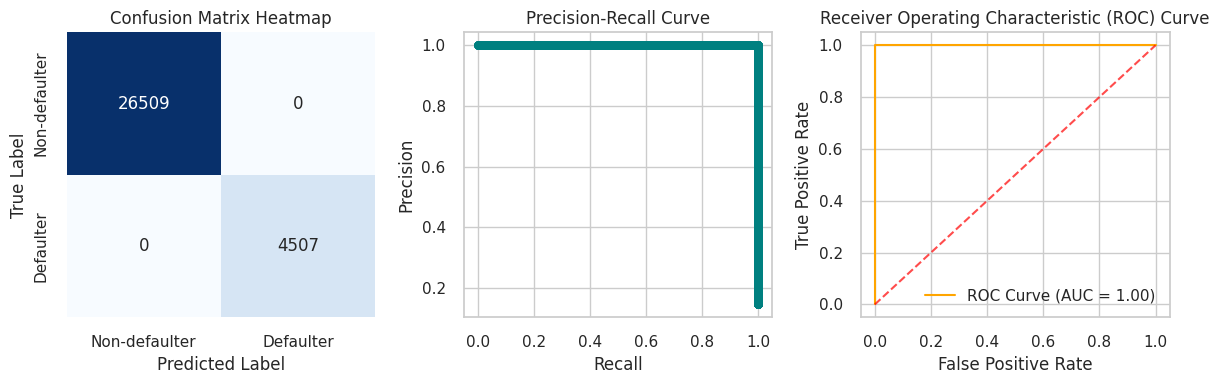

*****Classification Report and Plots for Test Dataset*****

Classification Report
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      6627
           1       0.29      0.09      0.14      1127

    accuracy                           0.84      7754
   macro avg       0.58      0.53      0.52      7754
weighted avg       0.78      0.84      0.80      7754



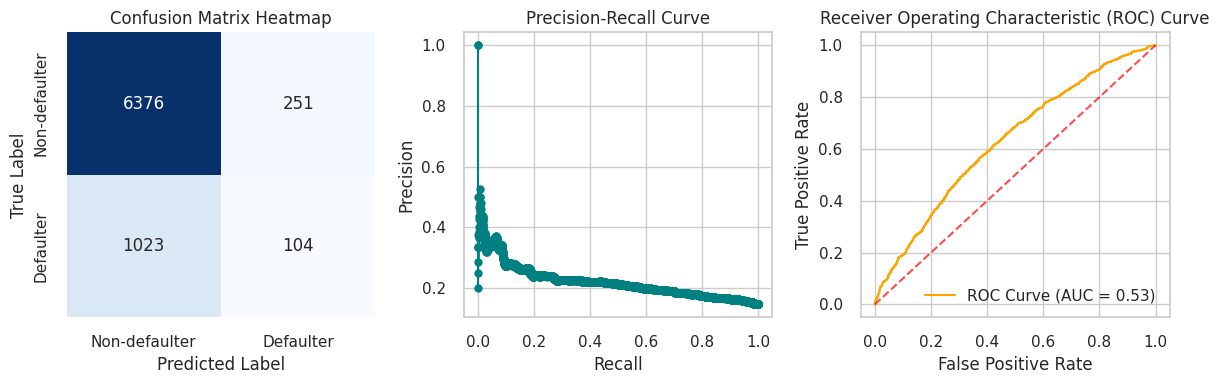

,Model,Precision_test,Recall_test,f1_test,Precision_train,Recall_train,f1_train
0,LogisticRegression,"[0.86, 0.65]","[1.0, 0.01]","[0.92, 0.02]","[0.86, 0.49]","[1.0, 0.01]","[0.92, 0.02]"
1,LogisticRegThreshold,"[0.91, 0.25]","[0.7, 0.6]","[0.79, 0.36]","[0.85, 0.0]","[1.0, 0.0]","[0.92, 0.0]"
2,RandomForest,"[0.86, 0.34]","[0.99, 0.02]","[0.92, 0.04]","[0.99, 1.0]","[1.0, 0.95]","[1.0, 0.97]"
3,RandomForestGS,"[0.9, 0.26]","[0.75, 0.53]","[0.82, 0.35]","[0.93, 0.31]","[0.75, 0.66]","[0.83, 0.42]"
4,XGBoost,"[0.86, 0.41]","[0.99, 0.06]","[0.92, 0.1]","[0.89, 0.97]","[1.0, 0.28]","[0.94, 0.44]"
5,xgboostRS,"[0.92, 0.22]","[0.57, 0.72]","[0.71, 0.34]","[0.94, 0.24]","[0.57, 0.8]","[0.71, 0.37]"
6,xgboostHyperParamSMOTE,"[0.86, 0.29]","[0.96, 0.09]","[0.91, 0.14]","[1.0, 1.0]","[1.0, 1.0]","[1.0, 1.0]"


In [93]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter grid for XGBoost
param_dist = {
    'n_estimators': [50, 100, 200, 300],                 # Number of trees
    'learning_rate': [0.01, 0.1, 0.2, 0.3],              # Learning rate
    'max_depth': [3, 5, 7, 10],                          # Maximum depth of each tree
    'min_child_weight': [1, 3, 5],                       # Minimum sum of instance weight (hessian) needed in a child
    'subsample': [0.6, 0.8, 1.0],                        # Subsample ratio of the training instance
    'colsample_bytree': [0.2, 0.6, 0.8, 1.0],                 # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.3, 0.5]                          # Minimum loss reduction required to make a further partition on a leaf node
}

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Set up RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist,n_iter=20, scoring='f1', cv=5, verbose=1, n_jobs=-1, random_state=42)

# Fit RandomizedSearchCV on the SMOTEd training data
xgb_random_search.fit(X_train_smote, y_train_smote)

# Get the best parameters and best estimator
best_params = xgb_random_search.best_params_
best_xgb_model = xgb_random_search.best_estimator_

print(f"Best Parameters: {best_params}")
#---------------------------------------------
# Make predictions on the train set using the best model
y_trainPred_xgbhpSmt_best = best_xgb_model.predict(X_train)

print("*****Classification Report and Plots for Test Dataset*****")

#Calculate Scores and Classification Report for test dataset
Calculate_scores('xgboostHyperParamSMOTE',y_train,y_trainPred_xgbhpSmt_best,False)

#Plot for test dataset
Plot_Reports(best_xgb_model,X_train,y_train,y_trainPred_xgbhpSmt_best)
#---------------------------------------------
# Make predictions on the test set using the best model
y_testPred_xgbhpSmt_best = best_xgb_model.predict(X_test)

print("*****Classification Report and Plots for Test Dataset*****")
#Calculate Scores and Classification Report for test dataset
Calculate_scores('xgboostHyperParamSMOTE',y_test,y_testPred_xgbhpSmt_best,True)

#Plot for test dataset
Plot_Reports(best_xgb_model,X_test,y_test,y_testPred_xgbhpSmt_best)
#---------------------------------------------
# Show scores
pd.merge(pd.DataFrame(precision_recall_test), pd.DataFrame(precision_recall_train), how='left', on='Model')

####Interpretation
**For Train Dataset**

**Confusion Matrix**
- True Negatives (TN): 26,509 The model correctly identified 26,509 non-default loans as non-default.
- False Positives (FP): 0 There were no non-default loans mistakenly classified as defaults.
- False Negatives (FN): 0 There were no default loans mistakenly classified as non-default.
- True Positives (TP): 4,507 The model correctly identified 4,507 default loans as defaults.

**Precision** = 1.00 for both the classes. The model has no false positives, meaning every prediction of default or non-default was correct.

**Recall** = 1.00 for both the classes.The model has no false negatives, meaning it correctly identifies every loan, whether it's a default or not.

**Precision-Recall Curve** : Model was able to correctly identify all the defaulted loans, without missing any.

**ROC Curve & AUC Score**  1.00 perfect discrimination between classes

------------------------------------------
**For Test Dataset**

**Confusion Matrix**
- True Negatives (TN) 6,376 The number of non-default loans correctly identified as non-default.
- False Positives (FP) 251 The number of non-default loans incorrectly predicted as default.
- False Negatives (FN) 1,023 The number of default loans incorrectly predicted as non-default.
- True Positives (TP) 104 The number of default loans correctly identified as default.

**Precision:** class 1 (Defaulter) = 0.29  meaning many false positives are being predicted for class 1 (defaulters).

**Recall**  class 1 (Defaulter) = 0.09, low, The model only correctly identifies 9% of the actual Defaulter cases, which is very low.

**Precision-Recall Curve** poor performance, with low recall and low precision for defaults, indicating that the model is failing to predict default loans properly.

**ROC Curve & AUC Score** 0.53, very naive, not able distinguish the class.

-----------------------------------------------
**Summary** The model is excellent at identifying non-default loans. This is useful for loan approvals, as it can confidently approve loans that are not likely to default, minimizing unnecessary interventions.

The major concern is with the prediction of defaults (Class 1). The low recall for defaults means that the model misses a lot of defaulted loans, which is risky for Lending Club


## Summary

Balanced Performers: Random Forest (Grid Search) and XGBoost with SMOTE show the most balanced results across metrics, making them better options for handling imbalanced data like defaulters.

Models like XGBoost (Hyperparameter Tuning with SMOTE) perform perfectly on training data, which could lead to overfitting. Testing performance should guide decision-making in tuning params.

Adjusting thresholds for Logistic Regression and Random Forest may further refine balance between precision and recall.

**To get better performance** -
Feature Transformation: logarithmic, polynomial, or interaction terms can be used to transform features and improve non-linear relationships.
Dimensionality Reduction: Principal Component Analysis (PCA) can be to reduce noise and improve efficiency.

**Negative Class Performance:** To improve the model's performance on the negative class, below can be considered:
- Resampling Techniques (e.g., oversampling the negative class or undersampling the positive class).
- Class Weights Adjustment in Random Forest, giving more weight to the negative class to help balance the performance.
- Exploring threshold tuning to adjust the decision boundary for better precision and recall for the negative class.

**Overfitting:** Overfitting appears to be present, especially in the performance difference between training and test data. Techniques such as cross-validation, early stopping, or further regularization could be useful to reduce overfitting.

**Feature Engineering:** Experimenting with more advanced feature selection or extraction techniques could help the model generalize better on the test set, particularly for the negative class.

#### Explainable AI: Model decisions through techniques like SHAP.
SHAP (SHapley Additive exPlanations) is a popular explainability framework in artificial intelligence and machine learning. It is used to interpret and understand the predictions of complex machine learning models by assigning an importance value (contribution) to each feature for a specific prediction. SHAP is based on cooperative game theory, specifically the Shapley values concept, which ensures fair attribution of contributions in a multi-player setting.



1.   Model-Agnostic: SHAP can be applied to any machine learning model, including black-box models like neural networks, random forests, and gradient boosting machines.
2.   Fair Feature Contribution: It fairly distributes the impact of each feature to the final prediction, considering all possible combinations of features
1.   Local Explanations: SHAP explains individual predictions by showing how each feature influenced that specific result.
2.   Feature Importance: Provides more nuanced feature importance scores than traditional methods

Here SHAP is used to get feature importance.
It displays the importance of each feature in the model. Features are ordered based on their average magnitude of SHAP values, which represent the feature's contribution to the model's prediction.

In [94]:
import shap
# Explain the model predictions using SHAP
xgb_model.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb_model)  # Works for tree-based models like RandomForest, XGBoost, LightGBM
shap_values = explainer.shap_values(X_test)  # Get SHAP value
#shap.summary_plot(shap_values, X_test)

In [95]:
shap_values = explainer.shap_values(X_test)

In [96]:
shap_values

array([[ 2.2914664e-01, -2.4757142e-01,  9.5517538e-02, ...,
         8.3104104e-01, -6.9499365e-06,  3.3318582e-03],
       [-4.4917207e-02,  6.0009396e-01, -1.1856213e-01, ...,
        -6.0950845e-02, -2.5679413e-03,  3.0692080e-03],
       [ 7.9628736e-01,  5.1243639e-01,  6.4869307e-02, ...,
        -4.9887218e-02,  1.6416653e-04,  9.7509110e-03],
       ...,
       [ 6.2226608e-02, -2.6272953e-01, -7.2174452e-02, ...,
        -4.3249693e-02, -3.9218599e-03,  3.1412919e-03],
       [ 3.8062426e-01, -2.5164673e-01,  1.5476377e-01, ...,
        -3.5688143e-02, -2.4134939e-04,  1.0184104e-03],
       [ 1.4454549e-02, -2.6391479e-01, -3.1114217e-02, ...,
        -4.3482795e-02, -4.1449163e-03,  4.1634501e-03]], dtype=float32)

In [97]:
lending_club_ds_new.columns

Index(['loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'pub_rec', 'revol_bal', 'loan_status', 'credit_lines',
       'credit_rate', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4',
       'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3',
       'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2',
       'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1',
       'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5',
       'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4',
       'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3',
       'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2',
       'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5', 'home_ownership_NONE',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'verification_status_Source Verified', 'verification_status_Verified',
       'purpose_credit_card', 'purpose_debt

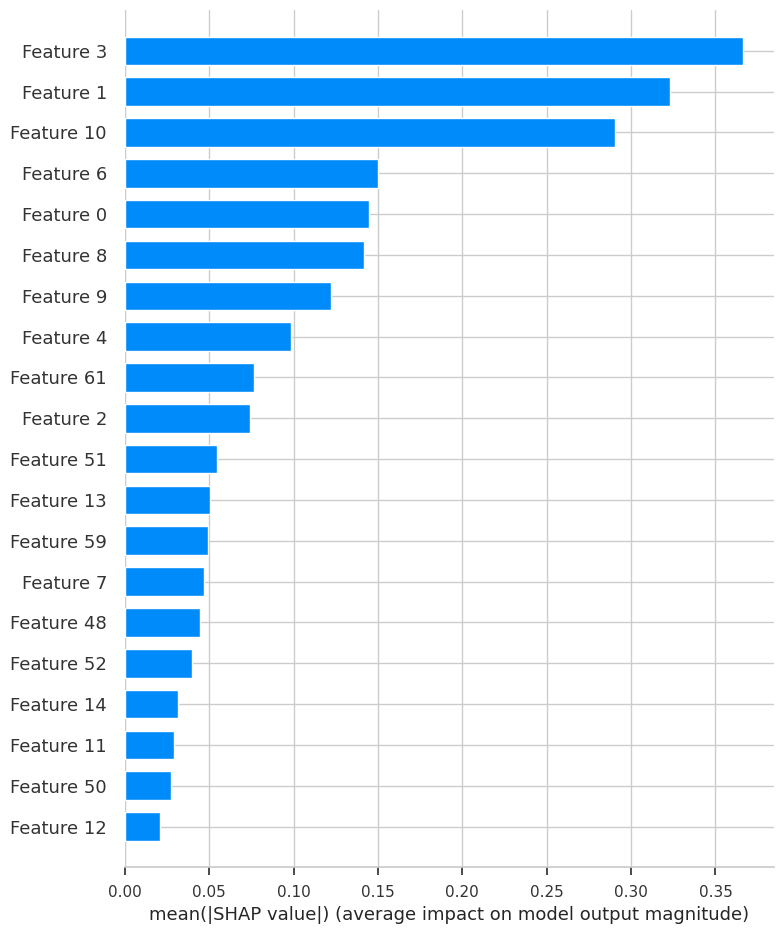

In [98]:
#SHAP Summary Plot (Shows Global Importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

From the feature imporatance graph following are the top 5 numerical_features that influence the loan_status
'annual_inc','term','credit_lines','loan_amnt','inq_last_6mths'

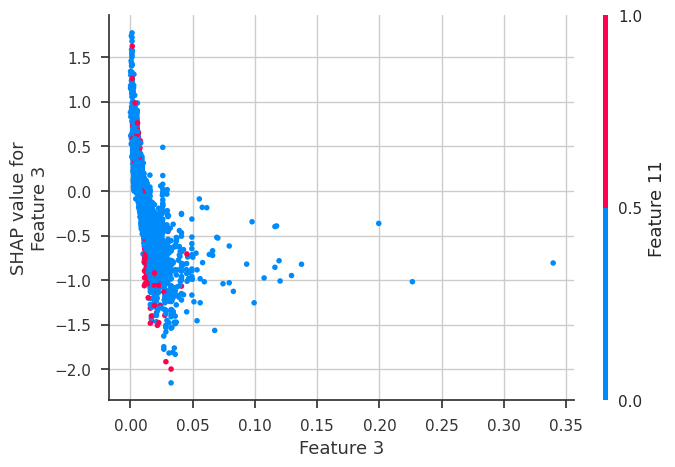

In [99]:
#SHAP Dependence Plot (For a Specific Feature)
shap.dependence_plot('Feature 3', shap_values, X_test)

####Interpretatiopn
- Most of the values for Feature 3 are concentrated near zero, with a few outliers extending towards 0.35.
- The impact on the model prediction is mostly negative as values of Feature 3 increase.
-Data points with higher Feature 11 values (pink/red) appear mostly at lower Feature 3 values.

#### LazyPredict
LazyPredict is a Python library designed to make machine learning model selection and evaluation easier and faster. It provides an automatic way to train and evaluate multiple machine learning models with minimal code. The idea behind LazyPredict is to quickly evaluate a large number of algorithms without requiring manual tuning of each model. This helps you get a baseline performance for different models on your dataset, making it easier to identify the best-performing models for your problem.

* Multiple Model Comparison: It runs a variety of machine learning models (like Random Forest, SVM, XGBoost, Logistic Regression, etc.) on your data, without requiring manual tuning.
* Automatic Model Evaluation: After training, LazyPredict provides performance metrics such as accuracy, AUC, F1 score, precision, recall, etc., for each model.
* Quick Baseline: It allows you to quickly get a baseline comparison of how different models perform, which is useful for model selection.
* Time-saving: Instead of manually coding each algorithm and hyperparameter tuning, LazyPredict handles most of the process.

In [101]:
from lazypredict.Supervised import LazyClassifier
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb  # Import lightgbm and give it the alias 'lgb'

# Load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize LazyClassifier
clf = LazyClassifier()
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

100%|██████████| 29/29 [00:01<00:00, 15.79it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 92
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.073920
[LightGBM] [Info] Start training from score -1.123930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [102]:
models # lists all the good model for Iris dataset.

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
AdaBoostClassifier,1.00,1.00,None,1.00,0.37
LabelSpreading,1.00,1.00,None,1.00,0.02
XGBClassifier,1.00,1.00,None,1.00,0.15
SVC,1.00,1.00,None,1.00,0.03
SGDClassifier,1.00,1.00,None,1.00,0.02
RandomForestClassifier,1.00,1.00,None,1.00,0.27
PassiveAggressiveClassifier,1.00,1.00,None,1.00,0.03
NuSVC,1.00,1.00,None,1.00,0.02
LogisticRegression,1.00,1.00,None,1.00,0.02


#### PyCaret
PyCaret is an open-source, low-code machine learning library in Python that simplifies the process of training and deploying ML models. It automates many aspects of ML workflows, including preprocessing, feature engineering, model selection, hyperparameter tuning, and deployment.
* Ease of Use: Single-line commands for tasks like model training, evaluation, and deployment.
* Automated ML Workflow: Handles data preprocessing, feature engineering, and model comparison.
* Multiple ML Models: Supports classification, regression, clustering, anomaly detection, NLP, and time series forecasting.
* Model Interpretability: Provides SHAP values and other interpretability tools.
Integration with Popular Frameworks: Works well with pandas, scikit-learn, XGBoost, LightGBM, and deep learning frameworks.

In [103]:
# to find best model using pycaret on iris data
from pycaret.classification import *
from pycaret.datasets import get_data

# Load dataset
data = get_data('iris')

# Set up the ML environment
s = setup(data, target='species')

# Compare different models
best_model = compare_models()

# Train and finalize the best model
final_model = finalize_model(best_model)

# Save model for deployment
save_model(final_model, 'best_iris_model')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.50,1.40,0.20,Iris-setosa
1,4.90,3.00,1.40,0.20,Iris-setosa
2,4.70,3.20,1.30,0.20,Iris-setosa
3,4.60,3.10,1.50,0.20,Iris-setosa
4,5.00,3.60,1.40,0.20,Iris-setosa


,Description,Value
0,Session id,8870
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Iris-setosa: 0, Iris-versicolor: 1, Iris-virginica: 2"
4,Original data shape,"(150, 5)"
5,Transformed data shape,"(150, 5)"
6,Transformed train set shape,"(105, 5)"
7,Transformed test set shape,"(45, 5)"
8,Numeric features,4
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.9718,0.0000,0.9718,0.9779,0.9710,0.9571,0.9607,0.0550
qda,Quadratic Discriminant Analysis,0.9709,0.0000,0.9709,0.9772,0.9700,0.9557,0.9595,0.0520
knn,K Neighbors Classifier,0.9618,0.9894,0.9618,0.9709,0.9614,0.9425,0.9473,0.0920
lr,Logistic Regression,0.9527,0.0000,0.9527,0.9595,0.9523,0.9286,0.9323,0.0780
et,Extra Trees Classifier,0.9436,0.9901,0.9436,0.9522,0.9428,0.9147,0.9196,0.3020
dt,Decision Tree Classifier,0.9336,0.9506,0.9336,0.9447,0.9328,0.8998,0.9059,0.1120
gbc,Gradient Boosting Classifier,0.9336,0.0000,0.9336,0.9447,0.9328,0.8998,0.9059,0.6810
lightgbm,Light Gradient Boosting Machine,0.9336,0.9785,0.9336,0.9447,0.9328,0.8998,0.9059,0.3490
nb,Naive Bayes,0.9245,0.9976,0.9245,0.9406,0.9229,0.8865,0.8954,0.0760
rf,Random Forest Classifier,0.9236,0.9933,0.9236,0.9402,0.9220,0.8853,0.8946,0.3710


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['sepal_length', 'sepal_width',
                                              'petal_length', 'petal_width'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empt...
                  TransformerWrapper(exclude=None, include=[],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               c

In [104]:
final_model # final model pipeline

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['sepal_length', 'sepal_width',
                                             'petal_length', 'petal_width'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empt...
                 TransformerWrapper(exclude=None, include=[],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='most_frequent'))),
                ('actual_estimator',
                 LinearDiscriminantAnalysis(covariance_estimator=None,
                                            n_components=None, priors=None,
                                            shrinkage=None, solver='svd',
                                            store_covariance=False,
                                            tol=0.0001))],
         verbose=False)